# 17. Prensa vs plataformas de participación

## Objetivo

Comparar cómo cambia el discurso sobre inmigración y LGTBI entre:

- Prensa digital
- Menéame
- ForoCoches
- YouTube

La pregunta principal es:

> ¿Cómo cambia el discurso cuando pasa de los medios de comunicación a los espacios de participación ciudadana?

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
import re

In [34]:
BASE = Path(
    r"C:\Users\herre\OneDrive\Desktop\Proyectos DATA\SPRINT 13"
)

RUTA_PRENSA = (
    BASE
    / "03_outputs"
    / "tables"
    / "prensa"
    / "prensa_nlp_comparacion.csv"
)

RUTA_RRSS = (
    BASE
    / "01_data"
    / "03_final"
    / "rrss"
    / "rrss_master.csv"
)

RUTA_PRENSA_COMPLETA = (
    BASE
    / "01_data"
    / "03_final"
    / "prensa"
    / "prensa_nlp_final.csv"
)

RUTA_TABLAS = (
    BASE
    / "03_outputs"
    / "tables"
    / "prensa_vs_plataformas"
)

RUTA_GRAFICOS = (
    BASE
    / "03_outputs"
    / "figures"
    / "prensa_vs_plataformas"
)

RUTA_TABLAS.mkdir(
    parents=True,
    exist_ok=True
)

RUTA_GRAFICOS.mkdir(
    parents=True,
    exist_ok=True
)

print("Prensa comparación:", RUTA_PRENSA.exists())
print("RRSS master:", RUTA_RRSS.exists())
print("Prensa completa:", RUTA_PRENSA_COMPLETA.exists())

Prensa comparación: True
RRSS master: True
Prensa completa: True


In [35]:
prensa = pd.read_csv(
    RUTA_PRENSA,
    encoding="utf-8-sig",
    low_memory=False
)

rrss = pd.read_csv(
    RUTA_RRSS,
    encoding="utf-8-sig",
    low_memory=False
)

## Estandarizar procedencia y plataforma

In [36]:
prensa_std = prensa.copy()
rrss_std = rrss.copy()

# Procedencia general
prensa_std["origen"] = "Prensa"
rrss_std["origen"] = "RRSS"

# Plataforma concreta
prensa_std["plataforma"] = "Prensa"

## Homogeneizar los temas general

In [37]:
def normalizar_tema(valor):

    valor = str(valor).strip().lower()

    if "|" in valor:
        return "Mixto"

    if "inmigr" in valor:
        return "Inmigración"

    if "lgtb" in valor:
        return "LGTBI"

    return valor


def normalizar_sentimiento(valor):

    valor = str(valor).strip().upper()

    equivalencias = {
        "NEG": "Negativo",
        "NEGATIVE": "Negativo",
        "NEGATIVO": "Negativo",

        "NEU": "Neutral",
        "NEUTRAL": "Neutral",

        "POS": "Positivo",
        "POSITIVE": "Positivo",
        "POSITIVO": "Positivo"
    }

    return equivalencias.get(
        valor,
        valor.title()
    )


for datos in [prensa_std, rrss_std]:

    datos["tema"] = (
        datos["tema"]
        .apply(normalizar_tema)
    )

    datos["sentimiento"] = (
        datos["sentimiento"]
        .apply(normalizar_sentimiento)
    )

## Comprobar que las categorías NLP coinciden

In [38]:
columnas_categoricas = [
    "tema",
    "sentimiento",
    "nivel_xenofobia",
    "nivel_lgtbifobia"
]

for columna in columnas_categoricas:

    print(f"\n===== {columna} =====")

    print(
        "Prensa:",
        sorted(
            prensa_std[columna]
            .dropna()
            .astype(str)
            .unique()
        )
    )

    print(
        "RRSS:",
        sorted(
            rrss_std[columna]
            .dropna()
            .astype(str)
            .unique()
        )
    )


===== tema =====
Prensa: ['Inmigración', 'LGTBI']
RRSS: ['Inmigración', 'LGTBI', 'Mixto']

===== sentimiento =====
Prensa: ['Negativo', 'Neutral', 'Positivo']
RRSS: ['Negativo', 'Neutral', 'Positivo']

===== nivel_xenofobia =====
Prensa: ['hostilidad_explicita', 'marco_conflictivo', 'neutro', 'sin_mencion', 'violencia_discriminacion']
RRSS: ['hostilidad_explicita', 'marco_conflictivo', 'neutro', 'sin_mencion', 'violencia_discriminacion']

===== nivel_lgtbifobia =====
Prensa: ['hostilidad_explicita', 'marco_conflictivo', 'neutro', 'sin_mencion', 'violencia_discriminacion']
RRSS: ['hostilidad_explicita', 'marco_conflictivo', 'neutro', 'sin_mencion', 'violencia_discriminacion']


## Crear el dataset conjunto para la comparación principal

In [39]:
columnas_comunes = [
    "anio",
    "origen",
    "plataforma",
    "tema",
    "sentimiento",
    "nivel_xenofobia",
    "nivel_lgtbifobia"
]

comparacion_nlp = pd.concat(
    [
        prensa_std[columnas_comunes],
        rrss_std[columnas_comunes]
    ],
    ignore_index=True
)

print(comparacion_nlp.shape)
display(comparacion_nlp.head())

(159328, 7)


,anio,origen,plataforma,tema,sentimiento,nivel_xenofobia,nivel_lgtbifobia
0,2015,Prensa,Prensa,Inmigración,Negativo,neutro,sin_mencion
1,2015,Prensa,Prensa,Inmigración,Negativo,marco_conflictivo,sin_mencion
2,2015,Prensa,Prensa,Inmigración,Neutral,neutro,sin_mencion
3,2015,Prensa,Prensa,Inmigración,Negativo,marco_conflictivo,sin_mencion
4,2015,Prensa,Prensa,Inmigración,Negativo,hostilidad_explicita,sin_mencion


## Validar la integración

In [40]:
display(
    comparacion_nlp
    .groupby(
        [
            "anio",
            "origen",
            "plataforma",
            "tema"
        ],
        dropna=False
    )
    .size()
    .reset_index(name="documentos")
)

,anio,origen,plataforma,tema,documentos
0,2015,Prensa,Prensa,Inmigración,9701
1,2015,Prensa,Prensa,LGTBI,1900
2,2015,RRSS,ForoCoches,Inmigración,827
3,2015,RRSS,ForoCoches,LGTBI,619
4,2015,RRSS,Menéame,Inmigración,2063
5,2015,RRSS,Menéame,LGTBI,888
6,2015,RRSS,YouTube,Inmigración,816
7,2015,RRSS,YouTube,LGTBI,2758
8,2016,Prensa,Prensa,Inmigración,11429
9,2016,Prensa,Prensa,LGTBI,2996


### Tratamiento de los temas automáticos

In [41]:
temas_prensa = prensa_std[
    [
        "anio",
        "tema",
        "bertopic_id",
        "bertopic_nombre"
    ]
].copy()

temas_rrss = rrss_std[
    [
        "anio",
        "plataforma",
        "tema",
        "topic"
    ]
].copy()

In [42]:
años_comunes = [
    2015,
    2016,
    2019,
    2023
]

comparacion_directa = (
    comparacion_nlp[
        comparacion_nlp["anio"].isin(años_comunes)
        & comparacion_nlp["tema"].isin(
            [
                "Inmigración",
                "LGTBI"
            ]
        )
    ]
    .copy()
)

display(
    comparacion_directa
    .groupby(
        [
            "anio",
            "origen",
            "tema"
        ]
    )
    .size()
    .reset_index(name="documentos")
)

,anio,origen,tema,documentos
0,2015,Prensa,Inmigración,9701
1,2015,Prensa,LGTBI,1900
2,2015,RRSS,Inmigración,3706
3,2015,RRSS,LGTBI,4265
4,2016,Prensa,Inmigración,11429
5,2016,Prensa,LGTBI,2996
6,2016,RRSS,Inmigración,7922
7,2016,RRSS,LGTBI,5641
8,2019,Prensa,Inmigración,15285
9,2019,Prensa,LGTBI,5712


### Distribución porcentual del sentimiento

In [43]:
distribucion_sentimiento = (
    comparacion_directa
    .groupby(
        [
            "anio",
            "origen",
            "tema",
            "sentimiento"
        ],
        observed=True
    )
    .size()
    .reset_index(name="documentos")
)

distribucion_sentimiento["porcentaje"] = (
    distribucion_sentimiento["documentos"]
    / distribucion_sentimiento
        .groupby(
            [
                "anio",
                "origen",
                "tema"
            ]
        )["documentos"]
        .transform("sum")
    * 100
).round(2)

display(distribucion_sentimiento)

,anio,origen,tema,sentimiento,documentos,porcentaje
0,2015,Prensa,Inmigración,Negativo,5295,54.58
1,2015,Prensa,Inmigración,Neutral,4138,42.66
2,2015,Prensa,Inmigración,Positivo,268,2.76
3,2015,Prensa,LGTBI,Negativo,902,47.47
4,2015,Prensa,LGTBI,Neutral,865,45.53
5,2015,Prensa,LGTBI,Positivo,133,7.00
6,2015,RRSS,Inmigración,Negativo,2287,61.71
7,2015,RRSS,Inmigración,Neutral,1086,29.30
8,2015,RRSS,Inmigración,Positivo,333,8.99
9,2015,RRSS,LGTBI,Negativo,1717,40.26


In [44]:
display(
    distribucion_sentimiento
    .groupby(
        [
            "anio",
            "origen",
            "tema"
        ]
    )["porcentaje"]
    .sum()
    .reset_index(name="suma_porcentaje")
)

,anio,origen,tema,suma_porcentaje
0,2015,Prensa,Inmigración,100.00
1,2015,Prensa,LGTBI,100.00
2,2015,RRSS,Inmigración,100.00
3,2015,RRSS,LGTBI,100.00
4,2016,Prensa,Inmigración,100.00
5,2016,Prensa,LGTBI,100.00
6,2016,RRSS,Inmigración,100.00
7,2016,RRSS,LGTBI,99.99
8,2019,Prensa,Inmigración,100.00
9,2019,Prensa,LGTBI,100.00


## Gráfico comparativo

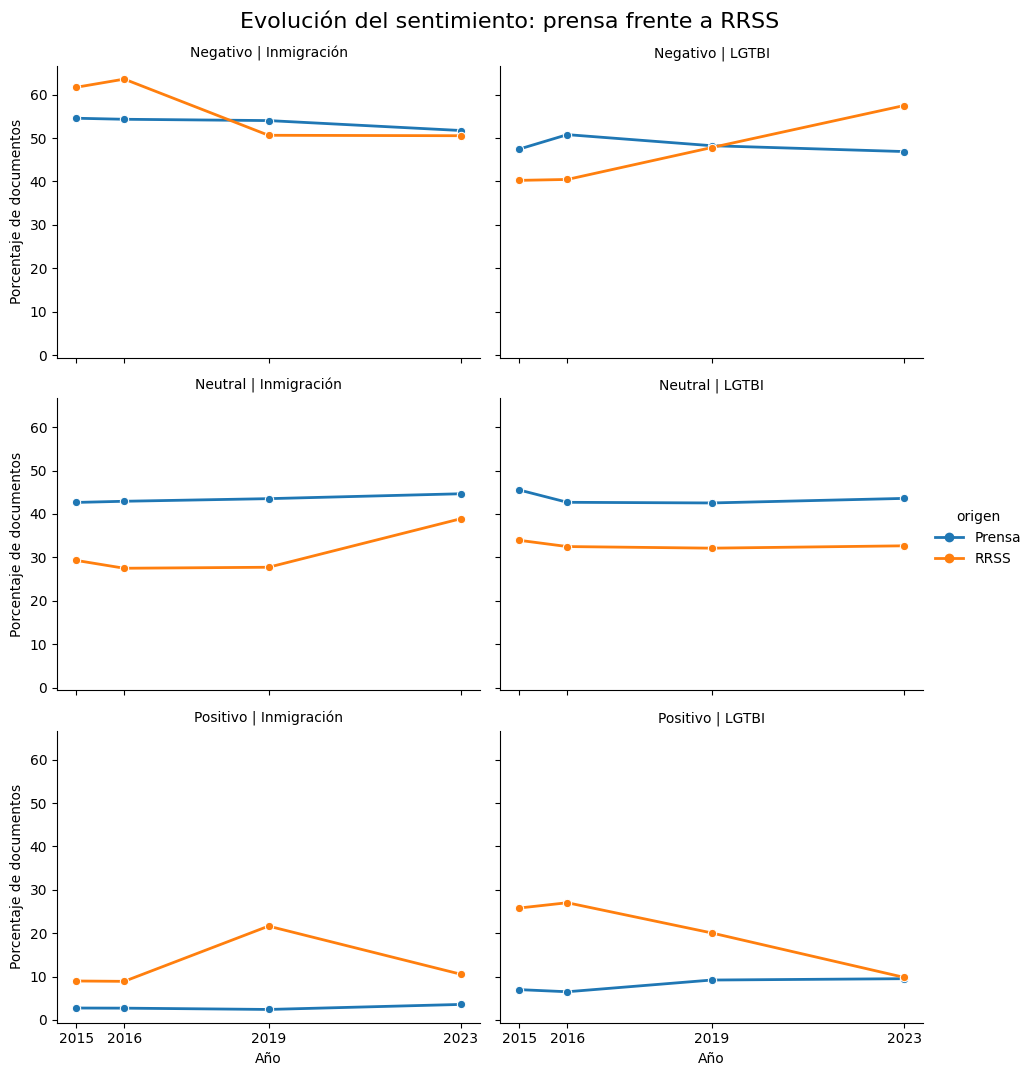

In [45]:
grafico_sentimiento = sns.relplot(
    data=distribucion_sentimiento,
    x="anio",
    y="porcentaje",
    hue="origen",
    row="sentimiento",
    col="tema",
    row_order=[
        "Negativo",
        "Neutral",
        "Positivo"
    ],
    col_order=[
        "Inmigración",
        "LGTBI"
    ],
    kind="line",
    marker="o",
    linewidth=2,
    height=3.5,
    aspect=1.35,
    facet_kws={
        "sharex": True,
        "sharey": True
    }
)

grafico_sentimiento.set_axis_labels(
    "Año",
    "Porcentaje de documentos"
)

grafico_sentimiento.set_titles(
    row_template="{row_name}",
    col_template="{col_name}"
)

for ax in grafico_sentimiento.axes.flat:
    ax.set_xticks(años_comunes)

grafico_sentimiento.fig.suptitle(
    "Evolución del sentimiento: prensa frente a RRSS",
    y=1.02,
    fontsize=16
)

plt.show()

## Tabla de diferencias entre RRSS y prensa

In [46]:
comparacion_sentimiento = (
    distribucion_sentimiento
    .pivot_table(
        index=[
            "anio",
            "tema",
            "sentimiento"
        ],
        columns="origen",
        values="porcentaje",
        fill_value=0
    )
    .reset_index()
)

comparacion_sentimiento["diferencia_RRSS_menos_Prensa"] = (
    comparacion_sentimiento["RRSS"]
    - comparacion_sentimiento["Prensa"]
).round(2)

display(comparacion_sentimiento)

origen,anio,tema,sentimiento,Prensa,RRSS,diferencia_RRSS_menos_Prensa
0,2015,Inmigración,Negativo,54.58,61.71,7.13
1,2015,Inmigración,Neutral,42.66,29.30,-13.36
2,2015,Inmigración,Positivo,2.76,8.99,6.23
3,2015,LGTBI,Negativo,47.47,40.26,-7.21
4,2015,LGTBI,Neutral,45.53,33.93,-11.60
5,2015,LGTBI,Positivo,7.00,25.81,18.81
6,2016,Inmigración,Negativo,54.34,63.60,9.26
7,2016,Inmigración,Neutral,42.93,27.49,-15.44
8,2016,Inmigración,Positivo,2.73,8.91,6.18
9,2016,LGTBI,Negativo,50.80,40.47,-10.33


## Xenofobia

In [47]:
print("Categorías de xenofobia en prensa:")

print(
    sorted(
        comparacion_directa.loc[
            comparacion_directa["origen"] == "Prensa",
            "nivel_xenofobia"
        ]
        .dropna()
        .unique()
    )
)

print("\nCategorías de xenofobia en RRSS:")

print(
    sorted(
        comparacion_directa.loc[
            comparacion_directa["origen"] == "RRSS",
            "nivel_xenofobia"
        ]
        .dropna()
        .unique()
    )
)

Categorías de xenofobia en prensa:
['hostilidad_explicita', 'marco_conflictivo', 'neutro', 'sin_mencion', 'violencia_discriminacion']

Categorías de xenofobia en RRSS:
['hostilidad_explicita', 'marco_conflictivo', 'neutro', 'sin_mencion', 'violencia_discriminacion']


In [48]:
# ========================================
# COMPARACIÓN DE XENOFOBIA
# ========================================

datos_xenofobia = (
    comparacion_directa[
        comparacion_directa["tema"] == "Inmigración"
    ]
    .copy()
)

distribucion_xenofobia = (
    datos_xenofobia
    .groupby(
        [
            "anio",
            "origen",
            "nivel_xenofobia"
        ],
        observed=True
    )
    .size()
    .reset_index(name="documentos")
)

distribucion_xenofobia["porcentaje"] = (
    distribucion_xenofobia["documentos"]
    / distribucion_xenofobia
        .groupby(
            [
                "anio",
                "origen"
            ]
        )["documentos"]
        .transform("sum")
    * 100
).round(2)

display(distribucion_xenofobia)

,anio,origen,nivel_xenofobia,documentos,porcentaje
0,2015,Prensa,hostilidad_explicita,451,4.65
1,2015,Prensa,marco_conflictivo,1803,18.59
2,2015,Prensa,neutro,7182,74.03
3,2015,Prensa,sin_mencion,250,2.58
4,2015,Prensa,violencia_discriminacion,15,0.15
5,2015,RRSS,hostilidad_explicita,98,2.64
6,2015,RRSS,marco_conflictivo,106,2.86
7,2015,RRSS,neutro,690,18.62
8,2015,RRSS,sin_mencion,2812,75.88
9,2016,Prensa,hostilidad_explicita,607,5.31


In [49]:
etiquetas_xenofobia = {
    "sin_mencion": "Sin mención",
    "neutro": "Neutro",
    "marco_conflictivo": "Marco conflictivo",
    "hostilidad_explicita": "Hostilidad explícita",
    "violencia_discriminacion": "Violencia o discriminación"
}

distribucion_xenofobia["nivel"] = (
    distribucion_xenofobia["nivel_xenofobia"]
    .map(etiquetas_xenofobia)
)

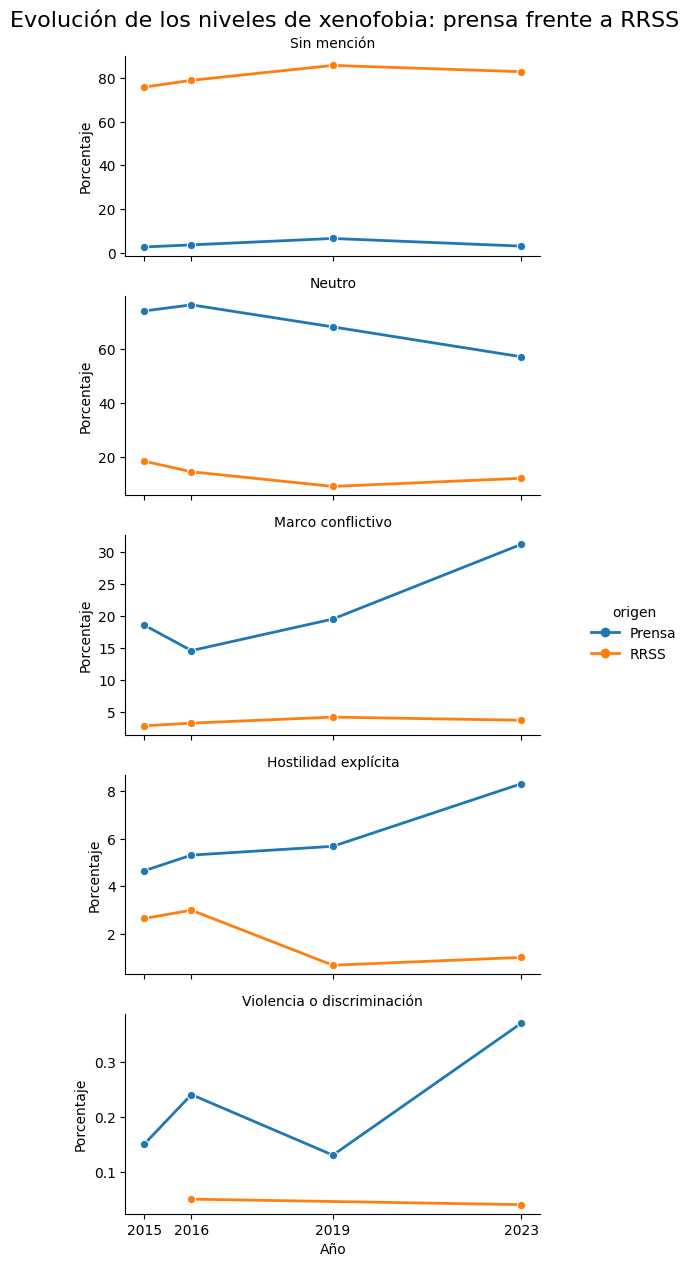

In [50]:
orden_xenofobia = [
    "Sin mención",
    "Neutro",
    "Marco conflictivo",
    "Hostilidad explícita",
    "Violencia o discriminación"
]

grafico_xenofobia = sns.relplot(
    data=distribucion_xenofobia,
    x="anio",
    y="porcentaje",
    hue="origen",
    row="nivel",
    row_order=orden_xenofobia,
    kind="line",
    marker="o",
    linewidth=2,
    height=2.5,
    aspect=2.0,
    facet_kws={
        "sharex": True,
        "sharey": False
    }
)

grafico_xenofobia.set_axis_labels(
    "Año",
    "Porcentaje"
)

grafico_xenofobia.set_titles(
    row_template="{row_name}"
)

for ax in grafico_xenofobia.axes.flat:
    ax.set_xticks(años_comunes)

grafico_xenofobia.fig.suptitle(
    "Evolución de los niveles de xenofobia: prensa frente a RRSS",
    y=1.01,
    fontsize=16
)

plt.show()

In [51]:
niveles_problematicos_xeno = [
    "marco_conflictivo",
    "hostilidad_explicita",
    "violencia_discriminacion"
]

datos_xenofobia["discurso_problematico"] = (
    datos_xenofobia["nivel_xenofobia"]
    .isin(niveles_problematicos_xeno)
)

resumen_xenofobia = (
    datos_xenofobia
    .groupby(
        [
            "anio",
            "origen"
        ]
    )["discurso_problematico"]
    .mean()
    .mul(100)
    .round(2)
    .reset_index(
        name="porcentaje_problematico"
    )
)

display(resumen_xenofobia)

,anio,origen,porcentaje_problematico
0,2015,Prensa,23.39
1,2015,RRSS,5.50
2,2016,Prensa,20.16
3,2016,RRSS,6.32
4,2019,Prensa,25.35
5,2019,RRSS,4.89
6,2023,Prensa,39.91
7,2023,RRSS,4.77


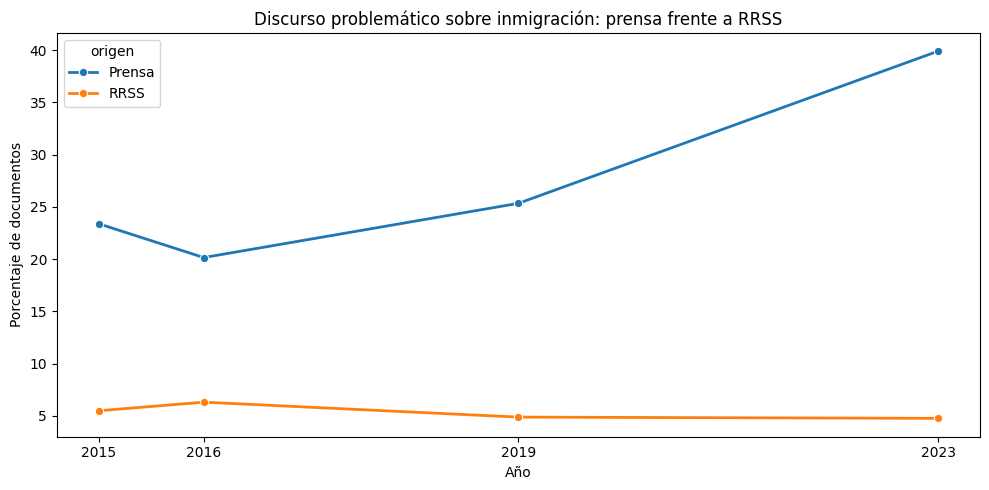

In [52]:
plt.figure(figsize=(10, 5))

sns.lineplot(
    data=resumen_xenofobia,
    x="anio",
    y="porcentaje_problematico",
    hue="origen",
    marker="o",
    linewidth=2
)

plt.title(
    "Discurso problemático sobre inmigración: prensa frente a RRSS"
)
plt.xlabel("Año")
plt.ylabel("Porcentaje de documentos")
plt.xticks(años_comunes)
plt.tight_layout()
plt.show()

In [53]:
prensa_textos = pd.read_csv(
    RUTA_PRENSA_COMPLETA,
    usecols=[
        "anio",
        "tema",
        "texto"
    ],
    encoding="utf-8-sig",
    low_memory=False
)

prensa_textos = pd.read_csv(
    RUTA_PRENSA_COMPLETA,
    usecols=[
        "anio",
        "tema",
        "texto"
    ],
    encoding="utf-8-sig",
    low_memory=False
)

In [54]:
prensa_textos["tema"] = (
    prensa_textos["tema"]
    .apply(normalizar_tema)
)

rrss_textos = rrss_std[
    [
        "anio",
        "tema",
        "texto"
    ]
].copy()

In [55]:
prensa_textos["palabras"] = (
    prensa_textos["texto"]
    .fillna("")
    .astype(str)
    .str.split()
    .str.len()
)

rrss_textos["palabras"] = (
    rrss_textos["texto"]
    .fillna("")
    .astype(str)
    .str.split()
    .str.len()
)

In [56]:
resumen_longitud = pd.DataFrame({
    "Prensa": prensa_textos["palabras"].describe(),
    "RRSS": rrss_textos["palabras"].describe()
})

display(resumen_longitud)

,Prensa,RRSS
count,75151.000000,84177.000000
mean,492.623531,27.430117
std,362.410894,49.735836
min,3.000000,1.000000
25%,256.000000,7.000000
50%,418.000000,15.000000
75%,644.000000,31.000000
max,11932.000000,5651.000000


In [57]:
resumen_longitud = pd.DataFrame({
    "Prensa": prensa_textos["palabras"].describe(),
    "RRSS": rrss_textos["palabras"].describe()
})

display(resumen_longitud)

,Prensa,RRSS
count,75151.000000,84177.000000
mean,492.623531,27.430117
std,362.410894,49.735836
min,3.000000,1.000000
25%,256.000000,7.000000
50%,418.000000,15.000000
75%,644.000000,31.000000
max,11932.000000,5651.000000


In [58]:
import sys

RUTA_DICCIONARIOS = (
    BASE
    / "scripts"
    / "diccionarios"
)

if str(RUTA_DICCIONARIOS) not in sys.path:
    sys.path.append(str(RUTA_DICCIONARIOS))

from diccionario_terminos import DICCIONARIO

print("Diccionario cargado correctamente")

Diccionario cargado correctamente


In [59]:
niveles_xeno = [
    "marco_conflictivo",
    "hostilidad_explicita",
    "violencia_discriminacion"
]

patrones_xeno = {}

for nivel in niveles_xeno:

    terminos = sorted(
        DICCIONARIO["xenofobia"][nivel],
        key=len,
        reverse=True
    )

    patron = (
        r"(?<!\w)(?:"
        + "|".join(
            re.escape(termino)
            for termino in terminos
        )
        + r")(?!\w)"
    )

    patrones_xeno[nivel] = re.compile(
        patron,
        flags=re.IGNORECASE
    )

In [60]:
textos_xeno = pd.concat(
    [
        prensa_textos.assign(origen="Prensa"),
        rrss_textos.assign(origen="RRSS")
    ],
    ignore_index=True
)

textos_xeno = (
    textos_xeno[
        textos_xeno["anio"].isin(años_comunes)
        & textos_xeno["tema"].eq("Inmigración")
    ]
    .copy()
)

In [61]:
def contar_palabras(texto):

    return len(
        re.findall(
            r"(?u)\b\w+\b",
            str(texto)
        )
    )


def contar_ocurrencias_xeno(texto):

    texto = str(texto)

    return {
        nivel: len(patron.findall(texto))
        for nivel, patron in patrones_xeno.items()
    }

In [62]:
textos_xeno["total_palabras"] = (
    textos_xeno["texto"]
    .fillna("")
    .apply(contar_palabras)
)

conteos_xeno = (
    textos_xeno["texto"]
    .fillna("")
    .apply(contar_ocurrencias_xeno)
    .apply(pd.Series)
)

textos_xeno = pd.concat(
    [
        textos_xeno.reset_index(drop=True),
        conteos_xeno.reset_index(drop=True)
    ],
    axis=1
)

textos_xeno["ocurrencias_problematicas"] = (
    textos_xeno[niveles_xeno]
    .sum(axis=1)
)

In [63]:
densidad_xenofobia = (
    textos_xeno
    .groupby(
        [
            "anio",
            "origen"
        ]
    )
    .agg(
        total_palabras=(
            "total_palabras",
            "sum"
        ),
        ocurrencias_problematicas=(
            "ocurrencias_problematicas",
            "sum"
        )
    )
    .reset_index()
)

densidad_xenofobia["ocurrencias_por_1000"] = (
    densidad_xenofobia["ocurrencias_problematicas"]
    / densidad_xenofobia["total_palabras"]
    * 1_000
).round(3)

display(densidad_xenofobia)

,anio,origen,total_palabras,ocurrencias_problematicas,ocurrencias_por_1000
0,2015,Prensa,4677048,3386,0.724
1,2015,RRSS,137242,131,0.955
2,2016,Prensa,5702687,3159,0.554
3,2016,RRSS,269711,264,0.979
4,2019,Prensa,6903336,7667,1.111
5,2019,RRSS,683915,858,1.255
6,2023,Prensa,10703083,18973,1.773
7,2023,RRSS,372540,448,1.203


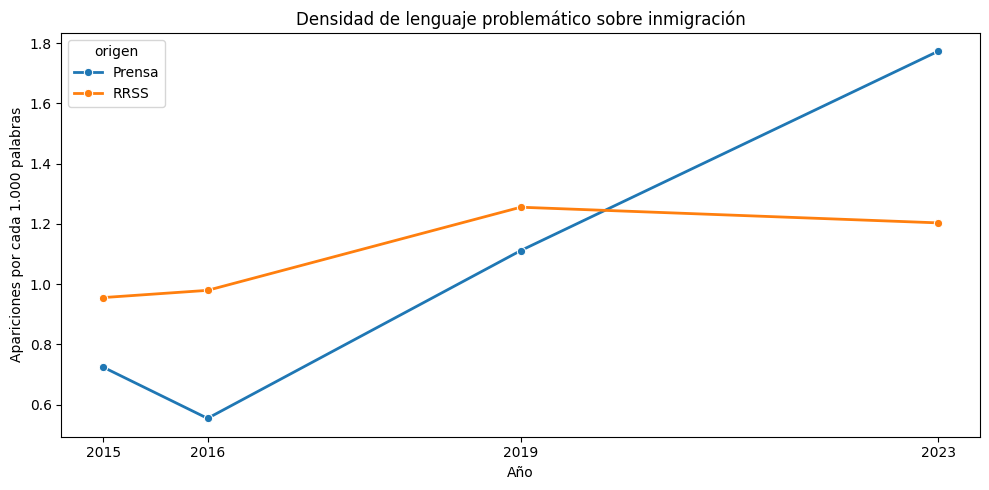

In [64]:
plt.figure(figsize=(10, 5))

sns.lineplot(
    data=densidad_xenofobia,
    x="anio",
    y="ocurrencias_por_1000",
    hue="origen",
    marker="o",
    linewidth=2
)

plt.title(
    "Densidad de lenguaje problemático sobre inmigración"
)
plt.xlabel("Año")
plt.ylabel(
    "Apariciones por cada 1.000 palabras"
)
plt.xticks(años_comunes)
plt.tight_layout()
plt.show()

### Descomponer la densidad por nivel

In [65]:
densidad_xeno_niveles = (
    textos_xeno
    .groupby(
        [
            "anio",
            "origen"
        ]
    )
    .agg(
        total_palabras=(
            "total_palabras",
            "sum"
        ),
        marco_conflictivo=(
            "marco_conflictivo",
            "sum"
        ),
        hostilidad_explicita=(
            "hostilidad_explicita",
            "sum"
        ),
        violencia_discriminacion=(
            "violencia_discriminacion",
            "sum"
        )
    )
    .reset_index()
)

densidad_xeno_niveles = (
    densidad_xeno_niveles
    .melt(
        id_vars=[
            "anio",
            "origen",
            "total_palabras"
        ],
        value_vars=niveles_xeno,
        var_name="nivel",
        value_name="ocurrencias"
    )
)

densidad_xeno_niveles["por_1000_palabras"] = (
    densidad_xeno_niveles["ocurrencias"]
    / densidad_xeno_niveles["total_palabras"]
    * 1_000
)

In [66]:
nombres_niveles_xeno = {
    "marco_conflictivo": "Marco conflictivo",
    "hostilidad_explicita": "Hostilidad explícita",
    "violencia_discriminacion": "Violencia o discriminación"
}

densidad_xeno_niveles["nivel_legible"] = (
    densidad_xeno_niveles["nivel"]
    .map(nombres_niveles_xeno)
)

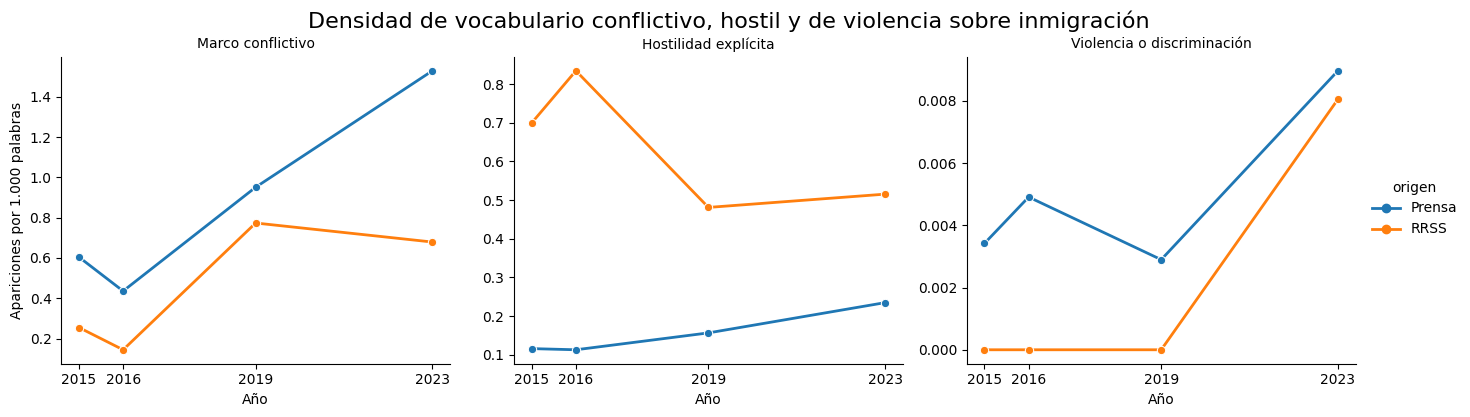

In [67]:
grafico_xeno_niveles = sns.relplot(
    data=densidad_xeno_niveles,
    x="anio",
    y="por_1000_palabras",
    hue="origen",
    col="nivel_legible",
    col_order=[
        "Marco conflictivo",
        "Hostilidad explícita",
        "Violencia o discriminación"
    ],
    kind="line",
    marker="o",
    linewidth=2,
    height=4,
    aspect=1.15,
    facet_kws={
        "sharex": True,
        "sharey": False
    }
)

grafico_xeno_niveles.set_axis_labels(
    "Año",
    "Apariciones por 1.000 palabras"
)

grafico_xeno_niveles.set_titles(
    "{col_name}"
)

for ax in grafico_xeno_niveles.axes.flat:
    ax.set_xticks(años_comunes)

grafico_xeno_niveles.fig.suptitle(
    "Densidad de vocabulario conflictivo, hostil y de violencia sobre inmigración",
    y=1.03,
    fontsize=16
)

plt.show()

# LGTBI

In [68]:
niveles_lgtbi = [
    "marco_conflictivo",
    "hostilidad_explicita",
    "violencia_discriminacion"
]

patrones_lgtbi = {}

for nivel in niveles_lgtbi:

    terminos = sorted(
        DICCIONARIO["lgtbifobia"][nivel],
        key=len,
        reverse=True
    )

    patron = (
        r"(?<!\w)(?:"
        + "|".join(
            re.escape(termino)
            for termino in terminos
        )
        + r")(?!\w)"
    )

    patrones_lgtbi[nivel] = re.compile(
        patron,
        flags=re.IGNORECASE
    )

In [69]:
textos_lgtbi = pd.concat(
    [
        prensa_textos.assign(origen="Prensa"),
        rrss_textos.assign(origen="RRSS")
    ],
    ignore_index=True
)

textos_lgtbi = (
    textos_lgtbi[
        textos_lgtbi["anio"].isin(años_comunes)
        & textos_lgtbi["tema"].eq("LGTBI")
    ]
    .copy()
)

In [70]:
def contar_ocurrencias_lgtbi(texto):

    texto = str(texto)

    return {
        nivel: len(patron.findall(texto))
        for nivel, patron in patrones_lgtbi.items()
    }


textos_lgtbi["total_palabras"] = (
    textos_lgtbi["texto"]
    .fillna("")
    .apply(contar_palabras)
)

conteos_lgtbi = (
    textos_lgtbi["texto"]
    .fillna("")
    .apply(contar_ocurrencias_lgtbi)
    .apply(pd.Series)
)

textos_lgtbi = pd.concat(
    [
        textos_lgtbi.reset_index(drop=True),
        conteos_lgtbi.reset_index(drop=True)
    ],
    axis=1
)

In [71]:
densidad_lgtbi_niveles = (
    textos_lgtbi
    .groupby(["anio", "origen"])
    .agg(
        total_palabras=("total_palabras", "sum"),
        marco_conflictivo=("marco_conflictivo", "sum"),
        hostilidad_explicita=("hostilidad_explicita", "sum"),
        violencia_discriminacion=(
            "violencia_discriminacion",
            "sum"
        )
    )
    .reset_index()
    .melt(
        id_vars=[
            "anio",
            "origen",
            "total_palabras"
        ],
        value_vars=niveles_lgtbi,
        var_name="nivel",
        value_name="ocurrencias"
    )
)

densidad_lgtbi_niveles["por_1000_palabras"] = (
    densidad_lgtbi_niveles["ocurrencias"]
    / densidad_lgtbi_niveles["total_palabras"]
    * 1_000
)

densidad_lgtbi_niveles["nivel_legible"] = (
    densidad_lgtbi_niveles["nivel"]
    .map(nombres_niveles_xeno)
)

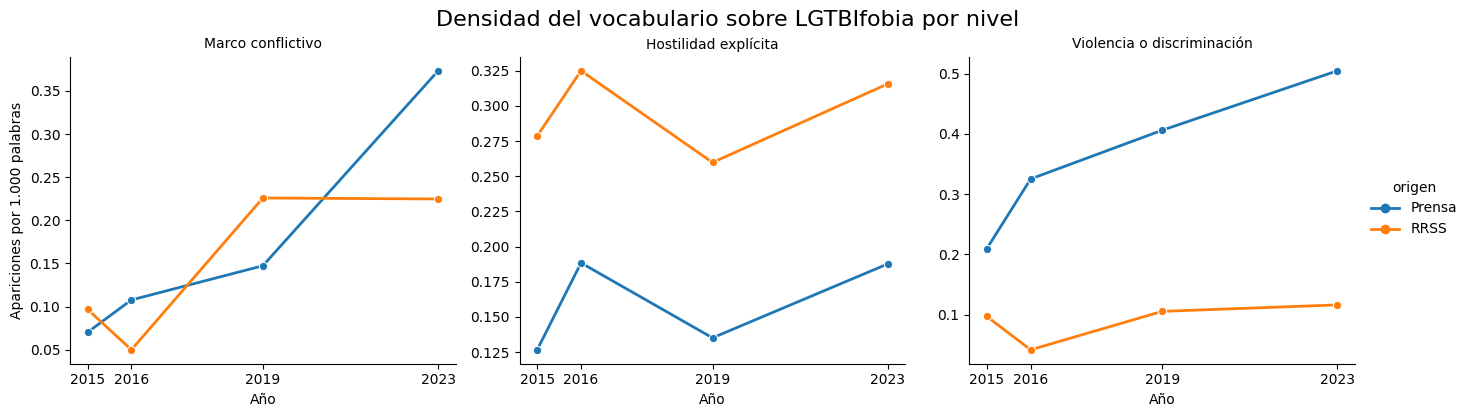

In [72]:
grafico_lgtbi_niveles = sns.relplot(
    data=densidad_lgtbi_niveles,
    x="anio",
    y="por_1000_palabras",
    hue="origen",
    col="nivel_legible",
    col_order=[
        "Marco conflictivo",
        "Hostilidad explícita",
        "Violencia o discriminación"
    ],
    kind="line",
    marker="o",
    linewidth=2,
    height=4,
    aspect=1.15,
    facet_kws={
        "sharex": True,
        "sharey": False
    }
)

grafico_lgtbi_niveles.set_axis_labels(
    "Año",
    "Apariciones por 1.000 palabras"
)

grafico_lgtbi_niveles.set_titles(
    "{col_name}"
)

for ax in grafico_lgtbi_niveles.axes.flat:
    ax.set_xticks(años_comunes)

grafico_lgtbi_niveles.fig.suptitle(
    "Densidad del vocabulario sobre LGTBIfobia por nivel",
    y=1.03,
    fontsize=16
)

plt.show()

# Comparación por plataforma

In [73]:
prensa_plataformas = (
    prensa_textos[
        [
            "anio",
            "tema",
            "texto"
        ]
    ]
    .copy()
)

prensa_plataformas["plataforma"] = "Prensa"

rrss_plataformas = (
    rrss_std[
        [
            "anio",
            "tema",
            "texto",
            "plataforma"
        ]
    ]
    .copy()
)

textos_plataformas = pd.concat(
    [
        prensa_plataformas,
        rrss_plataformas
    ],
    ignore_index=True
)

textos_plataformas = textos_plataformas[
    textos_plataformas["anio"].isin(años_comunes)
].copy()

In [74]:
def densidad_hostilidad_plataforma(
    datos,
    tema,
    patrones
):

    resultado = (
        datos[
            datos["tema"] == tema
        ]
        .copy()
    )

    resultado["total_palabras"] = (
        resultado["texto"]
        .fillna("")
        .apply(contar_palabras)
    )

    patron_hostilidad = (
        patrones["hostilidad_explicita"]
    )

    resultado["hostilidad"] = (
        resultado["texto"]
        .fillna("")
        .astype(str)
        .apply(
            lambda texto: len(
                patron_hostilidad.findall(texto)
            )
        )
    )

    resumen = (
        resultado
        .groupby(
            [
                "anio",
                "plataforma"
            ]
        )
        .agg(
            total_palabras=(
                "total_palabras",
                "sum"
            ),
            hostilidad=(
                "hostilidad",
                "sum"
            )
        )
        .reset_index()
    )

    resumen["por_1000_palabras"] = (
        resumen["hostilidad"]
        / resumen["total_palabras"]
        * 1_000
    )

    return resumen

In [75]:
hostilidad_xeno_plataforma = (
    densidad_hostilidad_plataforma(
        textos_plataformas,
        "Inmigración",
        patrones_xeno
    )
)

hostilidad_lgtbi_plataforma = (
    densidad_hostilidad_plataforma(
        textos_plataformas,
        "LGTBI",
        patrones_lgtbi
    )
)

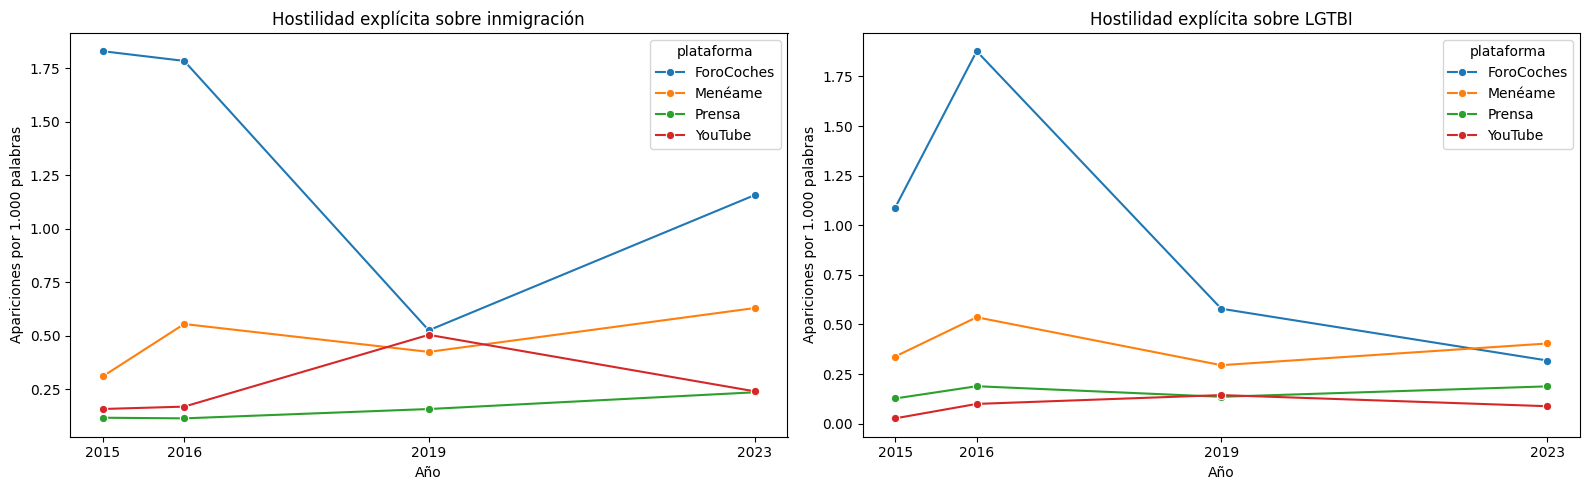

In [76]:
fig, axes = plt.subplots(
    1, 2,
    figsize=(16, 5),
    sharey=False
)

sns.lineplot(
    data=hostilidad_xeno_plataforma,
    x="anio",
    y="por_1000_palabras",
    hue="plataforma",
    marker="o",
    ax=axes[0]
)

axes[0].set_title(
    "Hostilidad explícita sobre inmigración"
)
axes[0].set_xlabel("Año")
axes[0].set_ylabel(
    "Apariciones por 1.000 palabras"
)
axes[0].set_xticks(años_comunes)

sns.lineplot(
    data=hostilidad_lgtbi_plataforma,
    x="anio",
    y="por_1000_palabras",
    hue="plataforma",
    marker="o",
    ax=axes[1]
)

axes[1].set_title(
    "Hostilidad explícita sobre LGTBI"
)
axes[1].set_xlabel("Año")
axes[1].set_ylabel(
    "Apariciones por 1.000 palabras"
)
axes[1].set_xticks(años_comunes)

plt.tight_layout()
plt.show()

In [77]:
textos_plataformas["total_palabras"] = (
    textos_plataformas["texto"]
    .fillna("")
    .apply(contar_palabras)
)

cobertura_plataformas = (
    textos_plataformas[
        textos_plataformas["tema"].isin(
            ["Inmigración", "LGTBI"]
        )
    ]
    .groupby(
        [
            "anio",
            "tema",
            "plataforma"
        ]
    )
    .agg(
        documentos=("texto", "size"),
        total_palabras=("total_palabras", "sum")
    )
    .reset_index()
)

cobertura_plataformas["cobertura_baja"] = (
    (cobertura_plataformas["documentos"] < 100)
    | (cobertura_plataformas["total_palabras"] < 10_000)
)

display(cobertura_plataformas)

,anio,tema,plataforma,documentos,total_palabras,cobertura_baja
0,2015,Inmigración,ForoCoches,827,37184,False
1,2015,Inmigración,Menéame,2063,80938,False
2,2015,Inmigración,Prensa,9701,4677048,False
3,2015,Inmigración,YouTube,816,19120,False
4,2015,LGTBI,ForoCoches,619,9189,True
5,2015,LGTBI,Menéame,888,35499,False
6,2015,LGTBI,Prensa,1900,939605,False
7,2015,LGTBI,YouTube,2758,37839,False
8,2016,Inmigración,ForoCoches,2444,74578,False
9,2016,Inmigración,Menéame,3405,153441,False


In [78]:
display(
    cobertura_plataformas[
        cobertura_plataformas["cobertura_baja"]
    ]
)

,anio,tema,plataforma,documentos,total_palabras,cobertura_baja
4,2015,LGTBI,ForoCoches,619,9189,True


In [79]:
print("Columnas prensa:")
print(prensa_std.columns.tolist())

print("\nColumnas RRSS:")
print(rrss_std.columns.tolist())

Columnas prensa:
['anio', 'origen', 'tema', 'sentimiento', 'nivel_xenofobia', 'nivel_lgtbifobia', 'bertopic_id', 'bertopic_nombre', 'plataforma']

Columnas RRSS:
['plataforma', 'anio', 'tema', 'texto', 'sentimiento', 'nivel_xenofobia', 'nivel_lgtbifobia', 'topic', 'interacciones', 'origen']


## Sentimiento por plataforma

In [90]:
prensa_ejemplos = prensa.reset_index(drop=True).copy()

prensa_ejemplos["texto"] = (
    prensa_textos["texto"]
    .reset_index(drop=True)
)

prensa_ejemplos["palabras"] = (
    prensa_textos["palabras"]
    .reset_index(drop=True)
)

In [91]:
# ==========================================
# EJEMPLOS REALES PARA EL HOVER
# ==========================================

# --------------------------
# 1. Preparar ejemplos de prensa
# --------------------------

prensa_ejemplos = (
    prensa
    .reset_index(drop=True)
    .copy()
)

prensa_ejemplos["texto"] = (
    prensa_textos["texto"]
    .reset_index(drop=True)
)

prensa_ejemplos = prensa_ejemplos.dropna(
    subset=[
        "texto",
        "tema",
        "sentimiento"
    ]
)

prensa_ejemplos["texto"] = (
    prensa_ejemplos["texto"]
    .astype(str)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

prensa_ejemplos = prensa_ejemplos[
    prensa_ejemplos["texto"].str.len() > 250
]

prensa_ejemplos = prensa_ejemplos.drop_duplicates(
    subset="texto"
)

prensa_ejemplos["plataforma"] = "Prensa"

# Ordenamos por longitud para obtener textos más completos
prensa_ejemplos["longitud"] = (
    prensa_ejemplos["texto"].str.len()
)

ejemplos_prensa = (
    prensa_ejemplos
    .sort_values(
        "longitud",
        ascending=False
    )
    .groupby(
        [
            "plataforma",
            "tema",
            "sentimiento"
        ],
        group_keys=False
    )
    .head(30)
    [
        [
            "plataforma",
            "tema",
            "sentimiento",
            "texto"
        ]
    ]
)


# --------------------------
# 2. Preparar ejemplos de RRSS
# --------------------------

rrss_ejemplos = rrss.copy()

rrss_ejemplos = rrss_ejemplos.dropna(
    subset=[
        "texto",
        "tema",
        "sentimiento",
        "plataforma"
    ]
)

rrss_ejemplos["texto"] = (
    rrss_ejemplos["texto"]
    .astype(str)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

# Evita comentarios demasiado cortos
rrss_ejemplos = rrss_ejemplos[
    rrss_ejemplos["texto"].str.len() > 60
]

rrss_ejemplos = rrss_ejemplos.drop_duplicates(
    subset="texto"
)

rrss_ejemplos["longitud"] = (
    rrss_ejemplos["texto"].str.len()
)

ejemplos_rrss = (
    rrss_ejemplos
    .sort_values(
        "longitud",
        ascending=False
    )
    .groupby(
        [
            "plataforma",
            "tema",
            "sentimiento"
        ],
        group_keys=False
    )
    .head(30)
    [
        [
            "plataforma",
            "tema",
            "sentimiento",
            "texto"
        ]
    ]
)


# --------------------------
# 3. Unir candidatos
# --------------------------

candidatos_hover = pd.concat(
    [
        ejemplos_prensa,
        ejemplos_rrss
    ],
    ignore_index=True
)

# Añadir identificador y columna de selección
candidatos_hover.insert(
    0,
    "id_ejemplo",
    range(1, len(candidatos_hover) + 1)
)

candidatos_hover["seleccionado"] = ""

# Ordenar para que el Excel sea fácil de revisar
candidatos_hover = candidatos_hover.sort_values(
    [
        "plataforma",
        "tema",
        "sentimiento"
    ]
).reset_index(drop=True)


# --------------------------
# 4. Exportar a Excel
# --------------------------

nombre_archivo = "candidatos_ejemplos_hover.xlsx"

with pd.ExcelWriter(
    nombre_archivo,
    engine="openpyxl"
) as writer:

    candidatos_hover.to_excel(
        writer,
        sheet_name="Todos",
        index=False
    )

    # Una hoja por plataforma
    for plataforma, grupo in candidatos_hover.groupby(
        "plataforma"
    ):

        nombre_hoja = str(plataforma)[:31]

        grupo.to_excel(
            writer,
            sheet_name=nombre_hoja,
            index=False
        )


print("Excel creado correctamente:")
print(nombre_archivo)
print("Filas:", len(candidatos_hover))

display(
    candidatos_hover.groupby(
        [
            "plataforma",
            "tema",
            "sentimiento"
        ]
    )
    .size()
    .reset_index(name="candidatos")
)

Excel creado correctamente:
candidatos_ejemplos_hover.xlsx
Filas: 734


,plataforma,tema,sentimiento,candidatos
0,ForoCoches,inmigracion,NEG,30
1,ForoCoches,inmigracion,NEU,30
2,ForoCoches,inmigracion,POS,30
3,ForoCoches,lgtbi,NEG,30
4,ForoCoches,lgtbi,NEU,30
5,ForoCoches,lgtbi,POS,30
6,Menéame,inmigracion,NEG,30
7,Menéame,inmigracion,NEU,30
8,Menéame,inmigracion,POS,30
9,Menéame,inmigracion|lgtbi,NEG,7


In [82]:
sentimiento_plataformas = (
    comparacion_directa
    .groupby(
        [
            "anio",
            "plataforma",
            "tema",
            "sentimiento"
        ],
        observed=True
    )
    .size()
    .reset_index(name="documentos")
)

sentimiento_plataformas["porcentaje"] = (
    sentimiento_plataformas["documentos"]
    / sentimiento_plataformas
        .groupby(
            [
                "anio",
                "plataforma",
                "tema"
            ]
        )["documentos"]
        .transform("sum")
    * 100
).round(2)

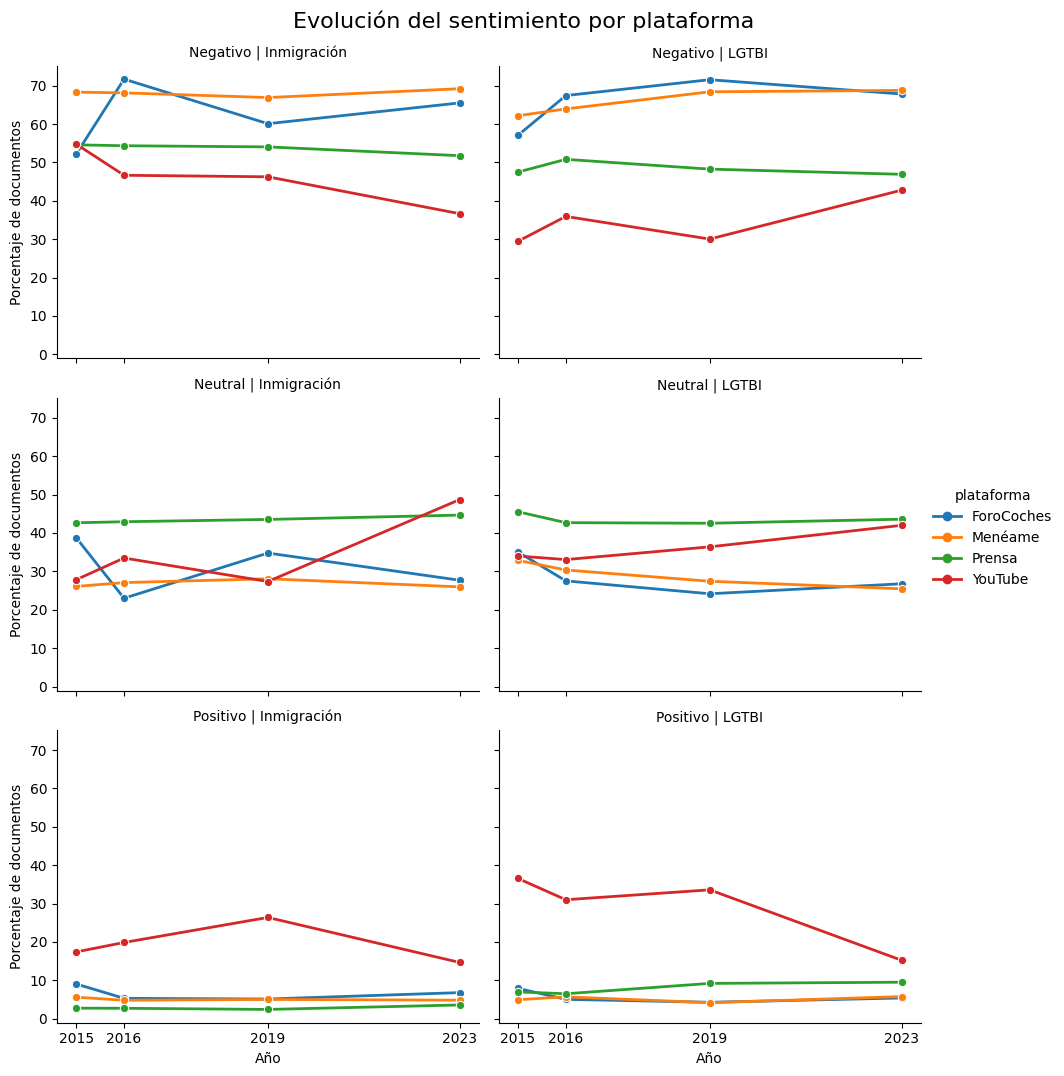

In [84]:
grafico_sentimiento_plataformas = sns.relplot(
    data=sentimiento_plataformas,
    x="anio",
    y="porcentaje",
    hue="plataforma",
    row="sentimiento",
    col="tema",
    row_order=[
        "Negativo",
        "Neutral",
        "Positivo"
    ],
    col_order=[
        "Inmigración",
        "LGTBI"
    ],
    kind="line",
    marker="o",
    linewidth=2,
    height=3.5,
    aspect=1.35,
    facet_kws={
        "sharex": True,
        "sharey": True
    }
)

grafico_sentimiento_plataformas.set_axis_labels(
    "Año",
    "Porcentaje de documentos"
)

grafico_sentimiento_plataformas.set_titles(
    row_template="{row_name}",
    col_template="{col_name}"
)

for ax in grafico_sentimiento_plataformas.axes.flat:
    ax.set_xticks(años_comunes)

grafico_sentimiento_plataformas.fig.suptitle(
    "Evolución del sentimiento por plataforma",
    y=1.02,
    fontsize=16
)

plt.show()

## Ponderar RRSS por interacciones

In [ ]:
rrss_interacciones = (
    rrss_std[
        rrss_std["anio"].isin(años_comunes)
        & rrss_std["tema"].isin(
            ["Inmigración", "LGTBI"]
        )
    ]
    .copy()
)

rrss_interacciones["interacciones"] = (
    pd.to_numeric(
        rrss_interacciones["interacciones"],
        errors="coerce"
    )
    .fillna(0)
    .clip(lower=0)
)

In [ ]:
rrss_interacciones["peso_interaccion"] = (
    1
    + np.log1p(
        rrss_interacciones["interacciones"]
    )
)

In [ ]:
sentimiento_ponderado = (
    rrss_interacciones
    .groupby(
        [
            "anio",
            "plataforma",
            "tema",
            "sentimiento"
        ]
    )["peso_interaccion"]
    .sum()
    .reset_index(name="peso")
)

sentimiento_ponderado["porcentaje_ponderado"] = (
    sentimiento_ponderado["peso"]
    / sentimiento_ponderado
        .groupby(
            [
                "anio",
                "plataforma",
                "tema"
            ]
        )["peso"]
        .transform("sum")
    * 100
).round(2)

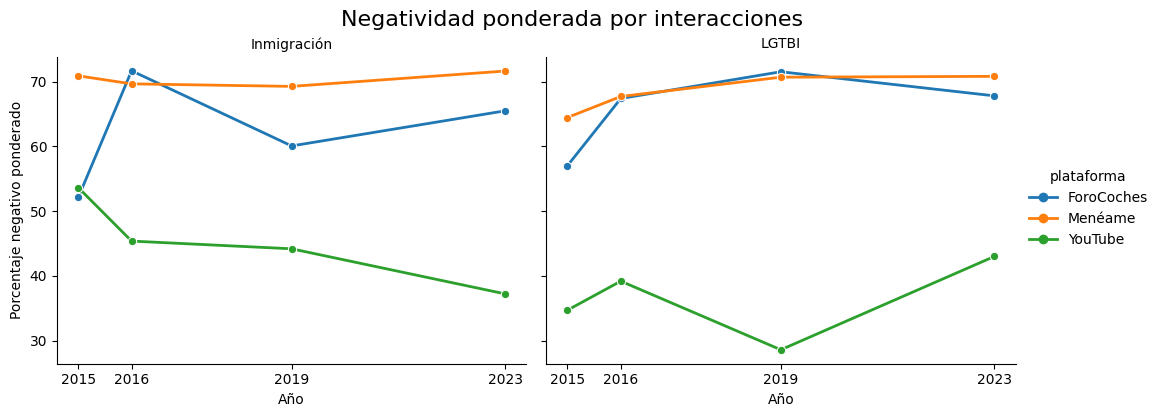

In [ ]:
negatividad_ponderada = (
    sentimiento_ponderado[
        sentimiento_ponderado["sentimiento"]
        == "Negativo"
    ]
)

grafico = sns.relplot(
    data=negatividad_ponderada,
    x="anio",
    y="porcentaje_ponderado",
    hue="plataforma",
    col="tema",
    col_order=[
        "Inmigración",
        "LGTBI"
    ],
    kind="line",
    marker="o",
    linewidth=2,
    height=4,
    aspect=1.3
)

grafico.set_axis_labels(
    "Año",
    "Porcentaje negativo ponderado"
)

grafico.set_titles("{col_name}")

for ax in grafico.axes.flat:
    ax.set_xticks(años_comunes)

grafico.fig.suptitle(
    "Negatividad ponderada por interacciones",
    y=1.03,
    fontsize=16
)

plt.show()

## Comparar negatividad ponderada y no ponderada

In [ ]:
negatividad_no_ponderada = (
    sentimiento_plataformas[
        sentimiento_plataformas["sentimiento"]
        == "Negativo"
    ][
        [
            "anio",
            "plataforma",
            "tema",
            "porcentaje"
        ]
    ]
    .rename(
        columns={
            "porcentaje":
            "porcentaje_no_ponderado"
        }
    )
)

negatividad_ponderada_tabla = (
    negatividad_ponderada[
        [
            "anio",
            "plataforma",
            "tema",
            "porcentaje_ponderado"
        ]
    ]
)

comparacion_ponderacion = (
    negatividad_no_ponderada
    .merge(
        negatividad_ponderada_tabla,
        on=[
            "anio",
            "plataforma",
            "tema"
        ],
        how="inner"
    )
)

comparacion_ponderacion[
    "cambio_por_interacciones"
] = (
    comparacion_ponderacion[
        "porcentaje_ponderado"
    ]
    - comparacion_ponderacion[
        "porcentaje_no_ponderado"
    ]
).round(2)

display(comparacion_ponderacion)

,anio,plataforma,tema,porcentaje_no_ponderado,porcentaje_ponderado,cambio_por_interacciones
0,2015,ForoCoches,Inmigración,52.12,52.12,0.00
1,2015,ForoCoches,LGTBI,57.03,57.03,0.00
2,2015,Menéame,Inmigración,68.30,70.91,2.61
3,2015,Menéame,LGTBI,62.16,64.47,2.31
4,2015,YouTube,Inmigración,54.78,53.65,-1.13
5,2015,YouTube,LGTBI,29.44,34.71,5.27
6,2016,ForoCoches,Inmigración,71.69,71.69,0.00
7,2016,ForoCoches,LGTBI,67.41,67.41,0.00
8,2016,Menéame,Inmigración,68.11,69.67,1.56
9,2016,Menéame,LGTBI,63.93,67.72,3.79


### Visualizar el efecto de la interacción

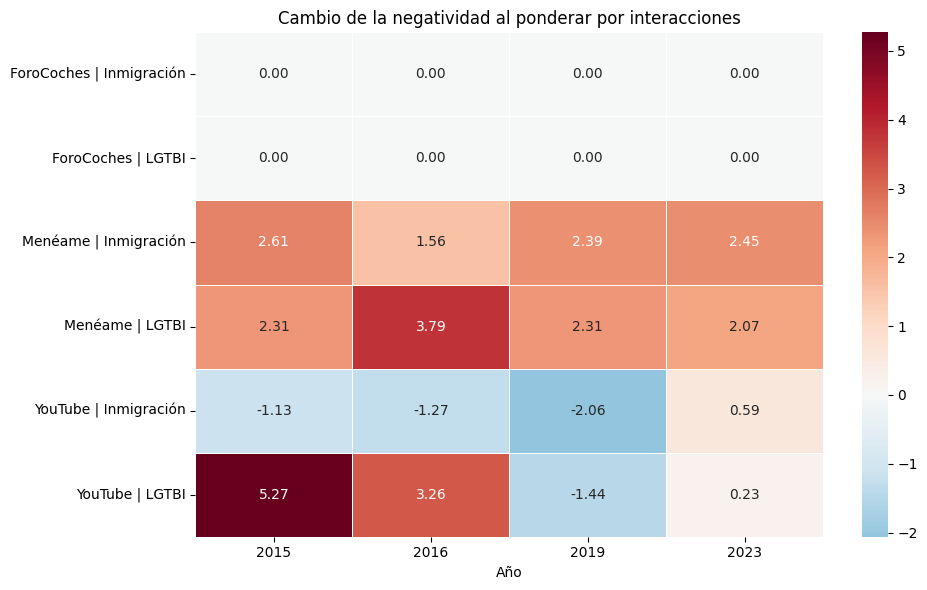

In [ ]:
tabla_calor = (
    comparacion_ponderacion
    .assign(
        grupo=lambda datos:
            datos["plataforma"]
            + " | "
            + datos["tema"]
    )
    .pivot(
        index="grupo",
        columns="anio",
        values="cambio_por_interacciones"
    )
)

plt.figure(figsize=(10, 6))

sns.heatmap(
    tabla_calor,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    linewidths=0.5
)

plt.title(
    "Cambio de la negatividad al ponderar por interacciones"
)
plt.xlabel("Año")
plt.ylabel("")
plt.tight_layout()
plt.show()

In [ ]:
diagnostico_interacciones = (
    rrss_std
    .assign(
        interacciones_num=pd.to_numeric(
            rrss_std["interacciones"],
            errors="coerce"
        )
    )
    .groupby("plataforma")
    .agg(
        documentos=(
            "interacciones_num",
            "size"
        ),
        valores_validos=(
            "interacciones_num",
            "count"
        ),
        valores_distintos=(
            "interacciones_num",
            "nunique"
        ),
        minimo=(
            "interacciones_num",
            "min"
        ),
        mediana=(
            "interacciones_num",
            "median"
        ),
        media=(
            "interacciones_num",
            "mean"
        ),
        maximo=(
            "interacciones_num",
            "max"
        )
    )
    .reset_index()
)

display(diagnostico_interacciones)

,plataforma,documentos,valores_validos,valores_distintos,minimo,mediana,media,maximo
0,ForoCoches,7400,0,0,NaN,NaN,NaN,NaN
1,Menéame,27490,27490,118,0.0,1.0,3.072499,220.0
2,YouTube,49287,49287,874,0.0,1.0,27.103049,36471.0


In [ ]:
interacciones_positivas = (
    rrss_std
    .assign(
        interacciones_num=pd.to_numeric(
            rrss_std["interacciones"],
            errors="coerce"
        )
    )
    .groupby("plataforma")[
        "interacciones_num"
    ]
    .apply(
        lambda serie: (serie > 0).sum()
    )
    .reset_index(
        name="interacciones_positivas"
    )
)

display(interacciones_positivas)

,plataforma,interacciones_positivas
0,ForoCoches,0
1,Menéame,15371
2,YouTube,25764


In [ ]:
comparacion_ponderacion_valida = (
    comparacion_ponderacion[
        comparacion_ponderacion["plataforma"]
        != "ForoCoches"
    ]
    .copy()
)

## Inspeccionar los temas de RRSS

In [ ]:
print("Número de temas RRSS:")
print(rrss_std["topic"].nunique())

temas_rrss_resumen = (
    rrss_std
    .groupby(
        [
            "tema",
            "topic"
        ],
        dropna=False
    )
    .agg(
        documentos=("topic", "size"),
        ejemplo=("texto", "first")
    )
    .reset_index()
    .sort_values(
        [
            "tema",
            "documentos"
        ],
        ascending=[True, False]
    )
)

display(
    temas_rrss_resumen.head(30)
)

Número de temas RRSS:
95


,tema,topic,documentos,ejemplo
94,Inmigración,NaN,20279,Unos inmigrantes en el mar en medio de una tem...
0,Inmigración,-1.0,15137,Qué triste. Es un ser humano.
2,Inmigración,1.0,1388,Llegaron tarde a la fiesta. Perón ya había pue...
5,Inmigración,4.0,958,"Me puse a llorar cuando veia el video, me sent..."
4,Inmigración,3.0,798,No se integran ni los bisnietos. No hay nada k...
8,Inmigración,7.0,521,¿ Qué sabrán estos nichardos de una ópera ? L...
11,Inmigración,10.0,518,Emirato marroquí de España 🇲🇦
13,Inmigración,12.0,498,"""El tono racista de Meslot"", lo dice un period..."
6,Inmigración,5.0,486,Bisabuelo.. Viniste al ped...🎵🎵🎶🎶😎😁
10,Inmigración,9.0,483,con todo respeto a todos los que participan en...


## Inspeccionar los temas de prensa

In [ ]:
print("Número de temas de prensa:")
print(prensa_std["bertopic_id"].nunique())

temas_prensa_resumen = (
    prensa_std
    .groupby(
        [
            "tema",
            "bertopic_id",
            "bertopic_nombre"
        ],
        dropna=False
    )
    .size()
    .reset_index(name="documentos")
    .sort_values(
        [
            "tema",
            "documentos"
        ],
        ascending=[True, False]
    )
)

display(
    temas_prensa_resumen.head(30)
)

Número de temas de prensa:
92


,tema,bertopic_id,bertopic_nombre,documentos
0,Inmigración,-1,-1_refugiados_personas_migrantes_país,18403
1,Inmigración,0,0_patera_salvamento_marítimo_salvamento marítimo,7019
2,Inmigración,1,1_canarias_gobierno_migrantes_menores,5763
3,Inmigración,2,2_alemania_merkel_refugiados_berlín,1504
4,Inmigración,3,3_policía_detenido_policía nacional_agentes,1331
5,Inmigración,4,4_trump_méxico_unidos_donald trump,837
6,Inmigración,5,5_open_arms_open arms_barco,835
7,Inmigración,6,6_refugiados_acogida_ayuntamiento_gobierno,831
8,Inmigración,7,7_ceuta_inmigrantes_valla_vallado,584
9,Inmigración,8,8_italia_meloni_salvini_italiano,567


## Ver los principales temas por separado

In [ ]:
display(
    temas_rrss_resumen[
        temas_rrss_resumen["tema"]
        == "Inmigración"
    ].head(15)
)

display(
    temas_rrss_resumen[
        temas_rrss_resumen["tema"]
        == "LGTBI"
    ].head(15)
)

,tema,topic,documentos,ejemplo
94,Inmigración,NaN,20279,Unos inmigrantes en el mar en medio de una tem...
0,Inmigración,-1.0,15137,Qué triste. Es un ser humano.
2,Inmigración,1.0,1388,Llegaron tarde a la fiesta. Perón ya había pue...
5,Inmigración,4.0,958,"Me puse a llorar cuando veia el video, me sent..."
4,Inmigración,3.0,798,No se integran ni los bisnietos. No hay nada k...
8,Inmigración,7.0,521,¿ Qué sabrán estos nichardos de una ópera ? L...
11,Inmigración,10.0,518,Emirato marroquí de España 🇲🇦
13,Inmigración,12.0,498,"""El tono racista de Meslot"", lo dice un period..."
6,Inmigración,5.0,486,Bisabuelo.. Viniste al ped...🎵🎵🎶🎶😎😁
10,Inmigración,9.0,483,con todo respeto a todos los que participan en...


,tema,topic,documentos,ejemplo
185,LGTBI,NaN,14595,¿Privada?
95,LGTBI,-1.0,9183,"La passsta manda, yo también soy ""friendly"" de..."
98,LGTBI,2.0,1197,Como que a veces me da risa cuando dice\n8.00...
96,LGTBI,0.0,1142,Y por que su dios tiene que meterse en mi vida...
110,LGTBI,14.0,447,Pero según dicen que la homosexualidad no esta...
101,LGTBI,5.0,409,Hola quiero que me ayuden ❤️😭😭😭😭😭
99,LGTBI,3.0,360,De verdad que no entiendo estar en contra de a...
104,LGTBI,8.0,335,5 años después veo este video. Hoy se cumple 1...
102,LGTBI,6.0,309,No entiendo como una Madre le hace eso a su hi...
121,LGTBI,25.0,263,Lo malo del cortometraje es que te quita la es...


In [ ]:
display(
    temas_prensa_resumen[
        temas_prensa_resumen["tema"]
        == "Inmigración"
    ].head(15)
)

display(
    temas_prensa_resumen[
        temas_prensa_resumen["tema"]
        == "LGTBI"
    ].head(15)
)

,tema,bertopic_id,bertopic_nombre,documentos
0,Inmigración,-1,-1_refugiados_personas_migrantes_país,18403
1,Inmigración,0,0_patera_salvamento_marítimo_salvamento marítimo,7019
2,Inmigración,1,1_canarias_gobierno_migrantes_menores,5763
3,Inmigración,2,2_alemania_merkel_refugiados_berlín,1504
4,Inmigración,3,3_policía_detenido_policía nacional_agentes,1331
5,Inmigración,4,4_trump_méxico_unidos_donald trump,837
6,Inmigración,5,5_open_arms_open arms_barco,835
7,Inmigración,6,6_refugiados_acogida_ayuntamiento_gobierno,831
8,Inmigración,7,7_ceuta_inmigrantes_valla_vallado,584
9,Inmigración,8,8_italia_meloni_salvini_italiano,567


,tema,bertopic_id,bertopic_nombre,documentos
92,LGTBI,-1,-1_lgtbi_personas_derechos_colectivo,7701
93,LGTBI,0,0_lgtbi_igualdad_ley_diversidad,817
94,LGTBI,1,1_fútbol_jankto_futbolista_jugador,490
95,LGTBI,2,2_orgullo_orgullo gay_madrid_gay,354
96,LGTBI,3,3_homosexualidad_cañizares_alcalá_obispado,348
97,LGTBI,4,4_orgullo_lgtbi_orgullo lgtbi_lgtbiq,345
98,LGTBI,5,5_acusado_víctima_hechos_prisión,343
99,LGTBI,6,6_película_personajes_serie_cine,293
100,LGTBI,7,7_bandera_bandera lgtbi_ayuntamiento_vox,281
101,LGTBI,8,8_rusia_propaganda_ruso_rusa,234


In [ ]:
print("Tipo de la columna topic:")
print(rrss_std["topic"].dtype)

print("\nNúmero de temas:")
print(rrss_std["topic"].nunique())

print("\nValores de topic:")
print(
    rrss_std["topic"]
    .drop_duplicates()
    .sort_values()
    .tolist()
)

Tipo de la columna topic:
float64

Número de temas:
95

Valores de topic:
[-1.0, 0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0, 12.0, 13.0, 14.0, 15.0, 16.0, 17.0, 18.0, 19.0, 20.0, 21.0, 22.0, 23.0, 24.0, 25.0, 26.0, 27.0, 28.0, 29.0, 30.0, 31.0, 32.0, 33.0, 34.0, 35.0, 36.0, 37.0, 38.0, 39.0, 40.0, 41.0, 42.0, 43.0, 44.0, 45.0, 46.0, 47.0, 48.0, 49.0, 50.0, 51.0, 52.0, 53.0, 54.0, 55.0, 56.0, 57.0, 58.0, 59.0, 60.0, 61.0, 62.0, 63.0, 64.0, 65.0, 66.0, 67.0, 68.0, 69.0, 70.0, 71.0, 72.0, 73.0, 74.0, 75.0, 76.0, 77.0, 78.0, 79.0, 80.0, 81.0, 82.0, 83.0, 84.0, 85.0, 86.0, 87.0, 88.0, 89.0, 90.0, 91.0, 92.0, 93.0, nan]


In [ ]:
temas_rrss_inmigracion = (
    temas_rrss_resumen[
        temas_rrss_resumen["tema"]
        == "Inmigración"
    ]
    .sort_values(
        "documentos",
        ascending=False
    )
    .head(20)
)

display(temas_rrss_inmigracion)

,tema,topic,documentos,ejemplo
94,Inmigración,NaN,20279,Unos inmigrantes en el mar en medio de una tem...
0,Inmigración,-1.0,15137,Qué triste. Es un ser humano.
2,Inmigración,1.0,1388,Llegaron tarde a la fiesta. Perón ya había pue...
5,Inmigración,4.0,958,"Me puse a llorar cuando veia el video, me sent..."
4,Inmigración,3.0,798,No se integran ni los bisnietos. No hay nada k...
8,Inmigración,7.0,521,¿ Qué sabrán estos nichardos de una ópera ? L...
11,Inmigración,10.0,518,Emirato marroquí de España 🇲🇦
13,Inmigración,12.0,498,"""El tono racista de Meslot"", lo dice un period..."
6,Inmigración,5.0,486,Bisabuelo.. Viniste al ped...🎵🎵🎶🎶😎😁
10,Inmigración,9.0,483,con todo respeto a todos los que participan en...


In [ ]:
temas_rrss_lgtbi = (
    temas_rrss_resumen[
        temas_rrss_resumen["tema"]
        == "LGTBI"
    ]
    .sort_values(
        "documentos",
        ascending=False
    )
    .head(20)
)

display(temas_rrss_lgtbi)

,tema,topic,documentos,ejemplo
185,LGTBI,NaN,14595,¿Privada?
95,LGTBI,-1.0,9183,"La passsta manda, yo también soy ""friendly"" de..."
98,LGTBI,2.0,1197,Como que a veces me da risa cuando dice\n8.00...
96,LGTBI,0.0,1142,Y por que su dios tiene que meterse en mi vida...
110,LGTBI,14.0,447,Pero según dicen que la homosexualidad no esta...
101,LGTBI,5.0,409,Hola quiero que me ayuden ❤️😭😭😭😭😭
99,LGTBI,3.0,360,De verdad que no entiendo estar en contra de a...
104,LGTBI,8.0,335,5 años después veo este video. Hoy se cumple 1...
102,LGTBI,6.0,309,No entiendo como una Madre le hace eso a su hi...
121,LGTBI,25.0,263,Lo malo del cortometraje es que te quita la es...


In [ ]:
cobertura_topics_rrss = (
    rrss_std
    .assign(
        tema_valido=lambda datos:
            datos["topic"].notna()
            & datos["topic"].ne(-1)
    )
    .groupby("tema")
    .agg(
        documentos=("topic", "size"),
        con_tema=("tema_valido", "sum")
    )
    .reset_index()
)

cobertura_topics_rrss["porcentaje_con_tema"] = (
    cobertura_topics_rrss["con_tema"]
    / cobertura_topics_rrss["documentos"]
    * 100
).round(2)

display(cobertura_topics_rrss)

,tema,documentos,con_tema,porcentaje_con_tema
0,Inmigración,50748,15332,30.21
1,LGTBI,33413,9635,28.84
2,Mixto,16,0,0.00


## Preparar los documentos agrupados por tema automático

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.corpus import stopwords

stopwords_es = list(
    stopwords.words("spanish")
)

rrss_topics_validos = (
    rrss_std[
        rrss_std["topic"].notna()
        & rrss_std["topic"].ne(-1)
        & rrss_std["tema"].isin(
            ["Inmigración", "LGTBI"]
        )
    ]
    .copy()
)

In [ ]:
def limpiar_para_topics(texto):

    texto = str(texto).lower()

    texto = re.sub(
        r"http\S+|www\.\S+",
        " ",
        texto
    )

    texto = re.sub(
        r"@\w+|#\d+",
        " ",
        texto
    )

    texto = re.sub(
        r"\s+",
        " ",
        texto
    )

    return texto.strip()


rrss_topics_validos["texto_topics"] = (
    rrss_topics_validos["texto"]
    .fillna("")
    .apply(limpiar_para_topics)
)

NameError: name 're' is not defined

## Obtener palabras distintivas por tema

In [ ]:
def obtener_etiquetas_topics(
    datos,
    tema_general,
    top_n=6
):

    grupos = (
        datos[
            datos["tema"] == tema_general
        ]
        .groupby("topic")
        .agg(
            texto=(
                "texto_topics",
                lambda textos: " ".join(textos)
            ),
            documentos=(
                "texto_topics",
                "size"
            )
        )
        .reset_index()
    )

    vectorizador = TfidfVectorizer(
        stop_words=stopwords_es,
        ngram_range=(1, 2),
        min_df=1,
        max_df=0.95,
        max_features=10_000
    )

    matriz = vectorizador.fit_transform(
        grupos["texto"]
    )

    vocabulario = (
        vectorizador
        .get_feature_names_out()
    )

    etiquetas = []

    for fila in matriz:

        indices = (
            fila.toarray()
            .ravel()
            .argsort()[-top_n:]
            [::-1]
        )

        terminos = [
            vocabulario[indice]
            for indice in indices
        ]

        etiquetas.append(
            ", ".join(terminos)
        )

    grupos["terminos_representativos"] = (
        etiquetas
    )

    grupos["tema"] = tema_general

    return grupos[
        [
            "tema",
            "topic",
            "documentos",
            "terminos_representativos"
        ]
    ]

## Generar tablas

In [ ]:
etiquetas_rrss_inmigracion = (
    obtener_etiquetas_topics(
        rrss_topics_validos,
        "Inmigración"
    )
)

etiquetas_rrss_lgtbi = (
    obtener_etiquetas_topics(
        rrss_topics_validos,
        "LGTBI"
    )
)

KeyError: "Column(s) ['texto_topics'] do not exist"

In [ ]:
display(
    etiquetas_rrss_inmigracion
    .sort_values(
        "documentos",
        ascending=False
    )
    .head(20)
)

display(
    etiquetas_rrss_lgtbi
    .sort_values(
        "documentos",
        ascending=False
    )
    .head(20)
)

NameError: name 'etiquetas_rrss_inmigracion' is not defined

In [ ]:
cobertura_topics_prensa = (
    prensa_std
    .assign(
        tema_valido=lambda datos:
            datos["bertopic_id"].notna()
            & datos["bertopic_id"].ne(-1)
    )
    .groupby("tema")
    .agg(
        documentos=("bertopic_id", "size"),
        con_tema=("tema_valido", "sum")
    )
    .reset_index()
)

cobertura_topics_prensa[
    "porcentaje_con_tema"
] = (
    cobertura_topics_prensa["con_tema"]
    / cobertura_topics_prensa["documentos"]
    * 100
).round(2)

cobertura_topics_prensa["origen"] = "Prensa"

cobertura_topics_rrss["origen"] = "RRSS"

cobertura_topics_comparada = pd.concat(
    [
        cobertura_topics_prensa,
        cobertura_topics_rrss[
            cobertura_topics_rrss["tema"]
            .isin(["Inmigración", "LGTBI"])
        ]
    ],
    ignore_index=True
)

display(cobertura_topics_comparada)

,tema,documentos,con_tema,porcentaje_con_tema,origen
0,Inmigración,56988,38585,67.71,Prensa
1,LGTBI,18163,10462,57.60,Prensa
2,Inmigración,50748,15332,30.21,RRSS
3,LGTBI,33413,9635,28.84,RRSS


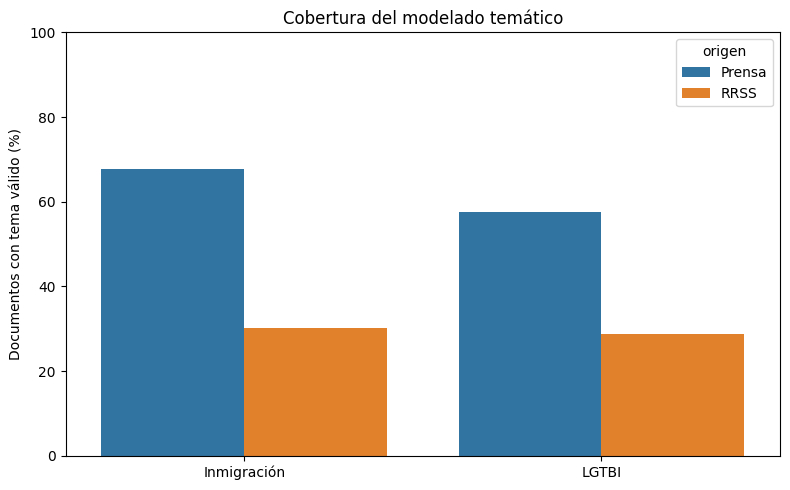

In [ ]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=cobertura_topics_comparada,
    x="tema",
    y="porcentaje_con_tema",
    hue="origen"
)

plt.title(
    "Cobertura del modelado temático"
)
plt.xlabel("")
plt.ylabel(
    "Documentos con tema válido (%)"
)
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

In [ ]:
display(
    etiquetas_rrss_inmigracion
    .sort_values("documentos", ascending=False)
    .head(20)
)

display(
    etiquetas_rrss_lgtbi
    .sort_values("documentos", ascending=False)
    .head(20)
)

,tema,topic,documentos,terminos_representativos
1,Inmigración,1.0,1388,"vox, votar, voto, españa, partido, elecciones"
4,Inmigración,4.0,958,"inmigrantes, inmigración, inmigrante, ilegal, ..."
3,Inmigración,3.0,798,"españa, si, vox, abascal, vamos, coges"
7,Inmigración,7.0,521,"canción, cancion, hermosa, hermosa canción, ll..."
10,Inmigración,10.0,518,"marruecos, marroquíes, españa, compartimos, ma..."
12,Inmigración,12.0,498,"españoles, vox, españa, presidente, partido, viva"
5,Inmigración,5.0,486,"españa, bla, bla bla, vox, viva, amén"
9,Inmigración,9.0,483,"españoles, español, españa, spanish, vox, viva"
6,Inmigración,6.0,466,"madre, padre, niño, padre madre, padres, años"
18,Inmigración,18.0,446,"españoles, inmigrantes, españa, ayudas, si, es..."


,tema,topic,documentos,terminos_representativos
2,LGTBI,2.0,1197,"gay, homosexual, homosexuales, homofobia, lgbt..."
0,LGTBI,0.0,1142,"dios, pecado, biblia, hijos dios, hijos, papa"
14,LGTBI,14.0,447,"rusia, madre rusia, rusos, madre, putin, viva ..."
5,LGTBI,5.0,409,"شعر, جميل, ام شعر, ام, ات, película película"
3,LGTBI,3.0,360,"si, pelicula, ja, vato, verdad, entiendo"
8,LGTBI,8.0,335,"video, vídeo, videos, vídeos, ver video, clip"
6,LGTBI,6.0,309,"niños, madre, padre, niño, hijo, padres"
25,LGTBI,25.0,263,"película, cortometraje, film, movie, short, sh..."
26,LGTBI,26.0,255,"dios, pecado, homosexualidad, homosexual, bibl..."
24,LGTBI,24.0,208,"gay, niños, hijo, padres, si, homosexual"


## Mapear temas de inmigración

In [ ]:
mapa_prensa_inmigracion = {
    0: "Fronteras y rutas",
    1: "Política e instituciones",
    2: "Fronteras y rutas",
    3: "Refugio y acogida",
    4: "Seguridad y justicia",
    5: "Política e instituciones",
    6: "Fronteras y rutas",
    7: "Política e instituciones",
    8: "Fronteras y rutas",
    9: "Seguridad y justicia",
    10: "Refugio y acogida",
    11: "Fronteras y rutas",
    12: "Política e instituciones",
    13: "Refugio y acogida"
}

mapa_rrss_inmigracion = {
    0: "Conversación general",
    1: "Política e instituciones",
    2: "Economía, trabajo y ayudas",
    3: "Política e instituciones",
    4: "Fronteras y migración irregular",
    5: "Religión e identidad",
    6: "Religión e identidad",
    7: "Cultura y entretenimiento",
    8: "Refugio y acogida",
    9: "Política e identidad nacional",
    10: "Fronteras y rutas",
    11: "Seguridad y justicia",
    12: "Política e instituciones",
    13: "Política e identidad nacional",
    15: "Seguridad y justicia",
    16: "Conflictos internacionales",
    17: "Religión e identidad",
    18: "Economía, trabajo y ayudas",
    19: "Política e instituciones",
    23: "Racismo y discriminación"
}

## Mapear temas LGTBI

In [ ]:
mapa_prensa_lgtbi = {
    0: "Derechos y política",
    1: "Deporte",
    2: "Orgullo y visibilidad",
    3: "Religión y moral",
    4: "Orgullo y visibilidad",
    5: "Seguridad y justicia",
    6: "Cultura y representación",
    7: "Orgullo y visibilidad",
    8: "Contexto internacional",
    9: "Identidades y orientación",
    10: "Seguridad y justicia",
    11: "Familias y matrimonio",
    12: "Violencia y discriminación",
    13: "Identidad trans y salud"
}

mapa_rrss_lgtbi = {
    0: "Religión y moral",
    1: "Derechos y política",
    2: "Identidades y orientación",
    3: "Derechos y política",
    4: "Violencia y discriminación",
    5: "Religión y moral",
    6: "Familias e infancia",
    7: "Cultura y representación",
    8: "Cultura y representación",
    9: "Conversación general",
    11: "Seguridad y justicia",
    14: "Contexto internacional",
    15: "Familias e infancia",
    17: "Orgullo y visibilidad",
    20: "Familias y reproducción",
    22: "Contexto internacional",
    24: "Identidad trans",
    25: "Cultura y representación",
    26: "Religión y moral",
    27: "Orgullo y visibilidad"
}

## Función para asignar las macrocategorías

In [ ]:
def asignar_macro_prensa(fila):

    topic = fila["bertopic_id"]

    if pd.isna(topic) or topic == -1:
        return "Sin tema"

    topic = int(topic)

    if fila["tema"] == "Inmigración":
        return mapa_prensa_inmigracion.get(
            topic,
            "Otros temas"
        )

    if fila["tema"] == "LGTBI":
        return mapa_prensa_lgtbi.get(
            topic,
            "Otros temas"
        )

    return "Otros temas"


def asignar_macro_rrss(fila):

    topic = fila["topic"]

    if pd.isna(topic) or topic == -1:
        return "Sin tema"

    topic = int(topic)

    if fila["tema"] == "Inmigración":
        return mapa_rrss_inmigracion.get(
            topic,
            "Otros temas"
        )

    if fila["tema"] == "LGTBI":
        return mapa_rrss_lgtbi.get(
            topic,
            "Otros temas"
        )

    return "Otros temas"

## Aplicar los mapas

In [ ]:
prensa_std["macrocategoria"] = (
    prensa_std.apply(
        asignar_macro_prensa,
        axis=1
    )
)

rrss_std["macrocategoria"] = (
    rrss_std.apply(
        asignar_macro_rrss,
        axis=1
    )
)

## Validar el resultado

In [ ]:
display(
    prensa_std[
        [
            "tema",
            "bertopic_id",
            "bertopic_nombre",
            "macrocategoria"
        ]
    ]
    .drop_duplicates()
    .sort_values(
        [
            "tema",
            "bertopic_id"
        ]
    )
    .head(40)
)

display(
    rrss_std[
        [
            "tema",
            "topic",
            "macrocategoria"
        ]
    ]
    .drop_duplicates()
    .sort_values(
        [
            "tema",
            "topic"
        ]
    )
    .head(40)
)

,tema,bertopic_id,bertopic_nombre,macrocategoria
1,Inmigración,-1,-1_refugiados_personas_migrantes_país,Sin tema
15,Inmigración,0,0_patera_salvamento_marítimo_salvamento marítimo,Fronteras y rutas
2,Inmigración,1,1_canarias_gobierno_migrantes_menores,Política e instituciones
116,Inmigración,2,2_alemania_merkel_refugiados_berlín,Fronteras y rutas
0,Inmigración,3,3_policía_detenido_policía nacional_agentes,Refugio y acogida
308,Inmigración,4,4_trump_méxico_unidos_donald trump,Seguridad y justicia
1070,Inmigración,5,5_open_arms_open arms_barco,Política e instituciones
10,Inmigración,6,6_refugiados_acogida_ayuntamiento_gobierno,Fronteras y rutas
108,Inmigración,7,7_ceuta_inmigrantes_valla_vallado,Política e instituciones
105,Inmigración,8,8_italia_meloni_salvini_italiano,Fronteras y rutas


,tema,topic,macrocategoria
34891,Inmigración,-1.0,Sin tema
35066,Inmigración,0.0,Conversación general
34988,Inmigración,1.0,Política e instituciones
34894,Inmigración,2.0,"Economía, trabajo y ayudas"
35065,Inmigración,3.0,Política e instituciones
34907,Inmigración,4.0,Fronteras y migración irregular
34974,Inmigración,5.0,Religión e identidad
34906,Inmigración,6.0,Religión e identidad
36091,Inmigración,7.0,Cultura y entretenimiento
35248,Inmigración,8.0,Refugio y acogida


In [ ]:
# ============================================================
# COBERTURA DE LAS MACROCATEGORÍAS ASIGNADAS
# ============================================================

def calcular_cobertura_macro(df, origen):
    resumen = (
        df.assign(
            tema_asignado=~df["macrocategoria"].isin(
                ["Sin tema", "Otros temas"]
            )
        )
        .groupby("tema", as_index=False)
        .agg(
            documentos=("macrocategoria", "size"),
            documentos_clasificados=("tema_asignado", "sum")
        )
    )

    resumen["porcentaje_clasificado"] = (
        resumen["documentos_clasificados"]
        / resumen["documentos"]
        * 100
    ).round(2)

    resumen["origen"] = origen

    return resumen


cobertura_prensa = calcular_cobertura_macro(
    prensa_std,
    "Prensa"
)

cobertura_rrss = calcular_cobertura_macro(
    rrss_std,
    "RRSS"
)

cobertura_macros = pd.concat(
    [cobertura_prensa, cobertura_rrss],
    ignore_index=True
)

display(cobertura_macros)

,tema,documentos,documentos_clasificados,porcentaje_clasificado,origen
0,Inmigración,56988,21916,38.46,Prensa
1,LGTBI,18163,4521,24.89,Prensa
2,Inmigración,50748,10059,19.82,RRSS
3,LGTBI,33413,6056,18.12,RRSS
4,Mixto,16,0,0.00,RRSS


In [ ]:
# ============================================================
# ARMONIZACIÓN DE NOMBRES ENTRE PRENSA Y RRSS
# ============================================================

equivalencias_macro = {
    "Fronteras y migración irregular": "Fronteras y rutas",
    "Política e identidad nacional": "Política e instituciones"
}

prensa_std["macrocategoria"] = (
    prensa_std["macrocategoria"]
    .replace(equivalencias_macro)
)

rrss_std["macrocategoria"] = (
    rrss_std["macrocategoria"]
    .replace(equivalencias_macro)
)

print("Macrocategorías de prensa:")
print(sorted(prensa_std["macrocategoria"].dropna().unique()))

print("\nMacrocategorías de RRSS:")
print(sorted(rrss_std["macrocategoria"].dropna().unique()))

Macrocategorías de prensa:
['Contexto internacional', 'Cultura y representación', 'Deporte', 'Derechos y política', 'Familias y matrimonio', 'Fronteras y rutas', 'Identidad trans y salud', 'Identidades y orientación', 'Orgullo y visibilidad', 'Otros temas', 'Política e instituciones', 'Refugio y acogida', 'Religión y moral', 'Seguridad y justicia', 'Sin tema', 'Violencia y discriminación']

Macrocategorías de RRSS:
['Conflictos internacionales', 'Contexto internacional', 'Conversación general', 'Cultura y entretenimiento', 'Cultura y representación', 'Derechos y política', 'Economía, trabajo y ayudas', 'Familias e infancia', 'Familias y reproducción', 'Fronteras y rutas', 'Identidad trans', 'Identidades y orientación', 'Orgullo y visibilidad', 'Otros temas', 'Política e instituciones', 'Racismo y discriminación', 'Refugio y acogida', 'Religión e identidad', 'Religión y moral', 'Seguridad y justicia', 'Sin tema', 'Violencia y discriminación']


In [ ]:
# ============================================================
# ARMONIZACIÓN FINAL DE MACROCATEGORÍAS
# ============================================================

equivalencias_finales = {
    # Categorías internacionales
    "Conflictos internacionales": "Contexto internacional",

    # Cultura
    "Cultura y entretenimiento": "Cultura y representación",

    # Familia
    "Familias y matrimonio": "Familias y reproducción",
    "Familias e infancia": "Familias y reproducción",

    # Identidad y diversidad sexual
    "Identidad trans": "Identidad y diversidad",
    "Identidad trans y salud": "Identidad y diversidad",
    "Identidades y orientación": "Identidad y diversidad"
}

for dataframe in [prensa_std, rrss_std]:
    dataframe["macrocategoria"] = (
        dataframe["macrocategoria"]
        .replace(equivalencias_finales)
    )

print("Macrocategorías de prensa:")
print(sorted(prensa_std["macrocategoria"].dropna().unique()))

print("\nMacrocategorías de RRSS:")
print(sorted(rrss_std["macrocategoria"].dropna().unique()))

Macrocategorías de prensa:
['Contexto internacional', 'Cultura y representación', 'Deporte', 'Derechos y política', 'Familias y reproducción', 'Fronteras y rutas', 'Identidad y diversidad', 'Orgullo y visibilidad', 'Otros temas', 'Política e instituciones', 'Refugio y acogida', 'Religión y moral', 'Seguridad y justicia', 'Sin tema', 'Violencia y discriminación']

Macrocategorías de RRSS:
['Contexto internacional', 'Conversación general', 'Cultura y representación', 'Derechos y política', 'Economía, trabajo y ayudas', 'Familias y reproducción', 'Fronteras y rutas', 'Identidad y diversidad', 'Orgullo y visibilidad', 'Otros temas', 'Política e instituciones', 'Racismo y discriminación', 'Refugio y acogida', 'Religión e identidad', 'Religión y moral', 'Seguridad y justicia', 'Sin tema', 'Violencia y discriminación']


In [ ]:
def calcular_cobertura_macro(df, origen):
    resultado = (
        df.assign(
            clasificado=~df["macrocategoria"].isin(
                ["Sin tema", "Otros temas"]
            )
        )
        .groupby("tema", as_index=False)
        .agg(
            documentos=("macrocategoria", "size"),
            documentos_clasificados=("clasificado", "sum")
        )
    )

    resultado["porcentaje_clasificado"] = (
        resultado["documentos_clasificados"]
        / resultado["documentos"]
        * 100
    ).round(2)

    resultado["origen"] = origen
    return resultado


cobertura_macros = pd.concat(
    [
        calcular_cobertura_macro(prensa_std, "Prensa"),
        calcular_cobertura_macro(rrss_std, "RRSS")
    ],
    ignore_index=True
)

display(
    cobertura_macros[
        [
            "origen",
            "tema",
            "documentos",
            "documentos_clasificados",
            "porcentaje_clasificado"
        ]
    ]
)

,origen,tema,documentos,documentos_clasificados,porcentaje_clasificado
0,Prensa,Inmigración,56988,21916,38.46
1,Prensa,LGTBI,18163,4521,24.89
2,RRSS,Inmigración,50748,10059,19.82
3,RRSS,LGTBI,33413,6056,18.12
4,RRSS,Mixto,16,0,0.00


In [ ]:
# ============================================================
# DISTRIBUCIÓN DE MACROCATEGORÍAS SOBRE EL CORPUS COMPLETO
# ============================================================

ANIOS_COMUNES = [2015, 2016, 2019, 2023]
TEMAS_COMUNES = ["Inmigración", "LGTBI"]

prensa_macro = prensa_std[
    prensa_std["anio"].isin(ANIOS_COMUNES)
    & prensa_std["tema"].isin(TEMAS_COMUNES)
].copy()

prensa_macro["origen"] = "Prensa"


rrss_macro = rrss_std[
    rrss_std["anio"].isin(ANIOS_COMUNES)
    & rrss_std["tema"].isin(TEMAS_COMUNES)
].copy()

rrss_macro["origen"] = "RRSS"


macro_comparacion = pd.concat(
    [
        prensa_macro[
            ["anio", "tema", "origen", "macrocategoria"]
        ],
        rrss_macro[
            ["anio", "tema", "origen", "macrocategoria"]
        ]
    ],
    ignore_index=True
)

# Comprobación
print("Años utilizados:")
print(sorted(macro_comparacion["anio"].unique()))

# Total de documentos por año, tema y origen
totales_macro = (
    macro_comparacion
    .groupby(["anio", "tema", "origen"])
    .size()
    .rename("total_documentos")
    .reset_index()
)

# Documentos de cada macrocategoría
distribucion_macro = (
    macro_comparacion
    .groupby(
        ["anio", "tema", "origen", "macrocategoria"]
    )
    .size()
    .rename("documentos")
    .reset_index()
)

distribucion_macro = distribucion_macro.merge(
    totales_macro,
    on=["anio", "tema", "origen"],
    how="left"
)

distribucion_macro["porcentaje_corpus"] = (
    distribucion_macro["documentos"]
    / distribucion_macro["total_documentos"]
    * 100
).round(2)

display(
    distribucion_macro
    .sort_values(
        ["tema", "anio", "origen", "porcentaje_corpus"],
        ascending=[True, True, True, False]
    )
    .head(30)
)

Años utilizados:
[np.int64(2015), np.int64(2016), np.int64(2019), np.int64(2023)]


,anio,tema,origen,macrocategoria,documentos,total_documentos,porcentaje_corpus
1,2015,Inmigración,Prensa,Otros temas,3822,9701,39.40
5,2015,Inmigración,Prensa,Sin tema,2830,9701,29.17
0,2015,Inmigración,Prensa,Fronteras y rutas,1837,9701,18.94
2,2015,Inmigración,Prensa,Política e instituciones,560,9701,5.77
4,2015,Inmigración,Prensa,Seguridad y justicia,470,9701,4.84
3,2015,Inmigración,Prensa,Refugio y acogida,182,9701,1.88
16,2015,Inmigración,RRSS,Sin tema,3232,3706,87.21
14,2015,Inmigración,RRSS,Religión e identidad,210,3706,5.67
10,2015,Inmigración,RRSS,Otros temas,117,3706,3.16
7,2015,Inmigración,RRSS,Conversación general,41,3706,1.11


In [ ]:
# ============================================================
# COMPARACIÓN GLOBAL CON DENOMINADOR CORRECTO
# ============================================================

categorias_excluidas = ["Sin tema", "Otros temas"]

# Total completo de documentos por origen y tema
totales_globales = (
    macro_comparacion
    .groupby(["tema", "origen"])
    .size()
    .rename("total_documentos")
    .reset_index()
)

# Documentos clasificados en cada macrocategoría
macro_global = (
    macro_comparacion[
        ~macro_comparacion["macrocategoria"].isin(
            categorias_excluidas
        )
    ]
    .groupby(
        ["tema", "origen", "macrocategoria"],
        as_index=False
    )
    .size()
    .rename(columns={"size": "documentos"})
)

macro_global = macro_global.merge(
    totales_globales,
    on=["tema", "origen"],
    how="left"
)

macro_global["porcentaje_corpus"] = (
    macro_global["documentos"]
    / macro_global["total_documentos"]
    * 100
).round(2)

display(
    macro_global.sort_values(
        ["tema", "origen", "porcentaje_corpus"],
        ascending=[True, True, False]
    )
)

,tema,origen,macrocategoria,documentos,total_documentos,porcentaje_corpus
0,Inmigración,Prensa,Fronteras y rutas,10461,56988,18.36
1,Inmigración,Prensa,Política e instituciones,7710,56988,13.53
2,Inmigración,Prensa,Refugio y acogida,2355,56988,4.13
3,Inmigración,Prensa,Seguridad y justicia,1390,56988,2.44
9,Inmigración,RRSS,Política e instituciones,4019,50748,7.92
8,Inmigración,RRSS,Fronteras y rutas,1476,50748,2.91
12,Inmigración,RRSS,Religión e identidad,1366,50748,2.69
13,Inmigración,RRSS,Seguridad y justicia,752,50748,1.48
7,Inmigración,RRSS,"Economía, trabajo y ayudas",528,50748,1.04
6,Inmigración,RRSS,Cultura y representación,521,50748,1.03


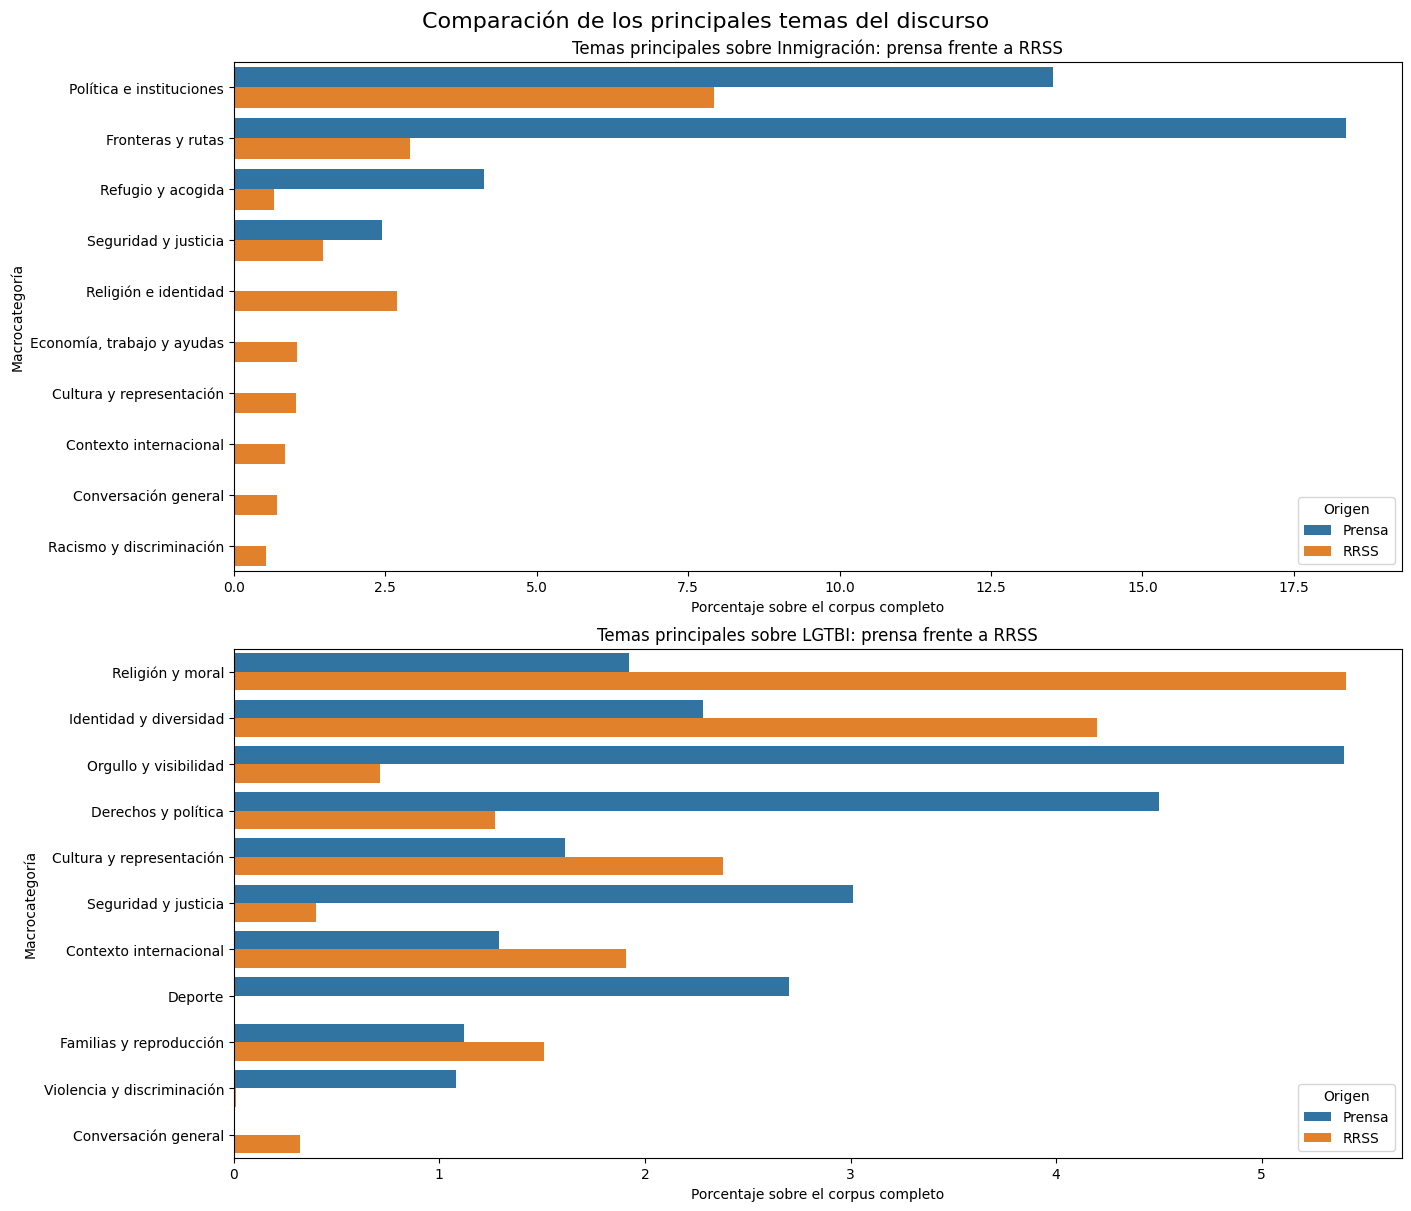

In [ ]:
fig, axes = plt.subplots(
    2, 1,
    figsize=(14, 12),
    constrained_layout=True
)

for ax, tema_actual in zip(
    axes,
    ["Inmigración", "LGTBI"]
):
    datos = macro_global[
        macro_global["tema"] == tema_actual
    ].copy()

    orden = (
        datos.groupby("macrocategoria")["porcentaje_corpus"]
        .sum()
        .sort_values(ascending=False)
        .index
    )

    sns.barplot(
        data=datos,
        y="macrocategoria",
        x="porcentaje_corpus",
        hue="origen",
        order=orden,
        ax=ax
    )

    ax.set_title(
        f"Temas principales sobre {tema_actual}: "
        "prensa frente a RRSS"
    )
    ax.set_xlabel("Porcentaje sobre el corpus completo")
    ax.set_ylabel("Macrocategoría")
    ax.legend(title="Origen")

fig.suptitle(
    "Comparación de los principales temas del discurso",
    fontsize=16
)

plt.show()

In [ ]:
# ============================================================
# EVOLUCIÓN TEMPORAL DE LAS MACROCATEGORÍAS PRINCIPALES
# ============================================================


def graficar_evolucion_macros(
    distribucion,
    tema_actual,
    numero_categorias=4
):
    datos = distribucion[
        (distribucion["tema"] == tema_actual)
        & (~distribucion["macrocategoria"].isin(
            ["Sin tema", "Otros temas"]
        ))
    ].copy()

    # Seleccionar las categorías con mayor peso medio
    categorias_principales = (
        datos.groupby("macrocategoria")["porcentaje_corpus"]
        .mean()
        .sort_values(ascending=False)
        .head(numero_categorias)
        .index
        .tolist()
    )

    datos = datos[
        datos["macrocategoria"].isin(categorias_principales)
    ].copy()

    # Incorporar ceros cuando una categoría no aparece
    combinaciones = pd.MultiIndex.from_product(
        [
            sorted(datos["anio"].unique()),
            ["Prensa", "RRSS"],
            categorias_principales
        ],
        names=["anio", "origen", "macrocategoria"]
    )

    datos = (
        datos.set_index(
            ["anio", "origen", "macrocategoria"]
        )
        .reindex(combinaciones)
        .reset_index()
    )

    datos["tema"] = tema_actual
    datos["porcentaje_corpus"] = (
        datos["porcentaje_corpus"].fillna(0)
    )

    fig, axes = plt.subplots(
        2,
        2,
        figsize=(14, 9),
        sharex=True,
        constrained_layout=True
    )

    axes = axes.flatten()

    for ax, categoria in zip(
        axes,
        categorias_principales
    ):
        datos_categoria = datos[
            datos["macrocategoria"] == categoria
        ]

        sns.lineplot(
            data=datos_categoria,
            x="anio",
            y="porcentaje_corpus",
            hue="origen",
            marker="o",
            ax=ax
        )

        ax.set_title(categoria)
        ax.set_xlabel("Año")
        ax.set_ylabel("Porcentaje del corpus")
        ax.set_xticks([2015, 2016, 2019, 2023])
        ax.legend(title="Origen")

    fig.suptitle(
        f"Evolución de los principales temas sobre "
        f"{tema_actual}: prensa frente a RRSS",
        fontsize=16
    )

    plt.show()

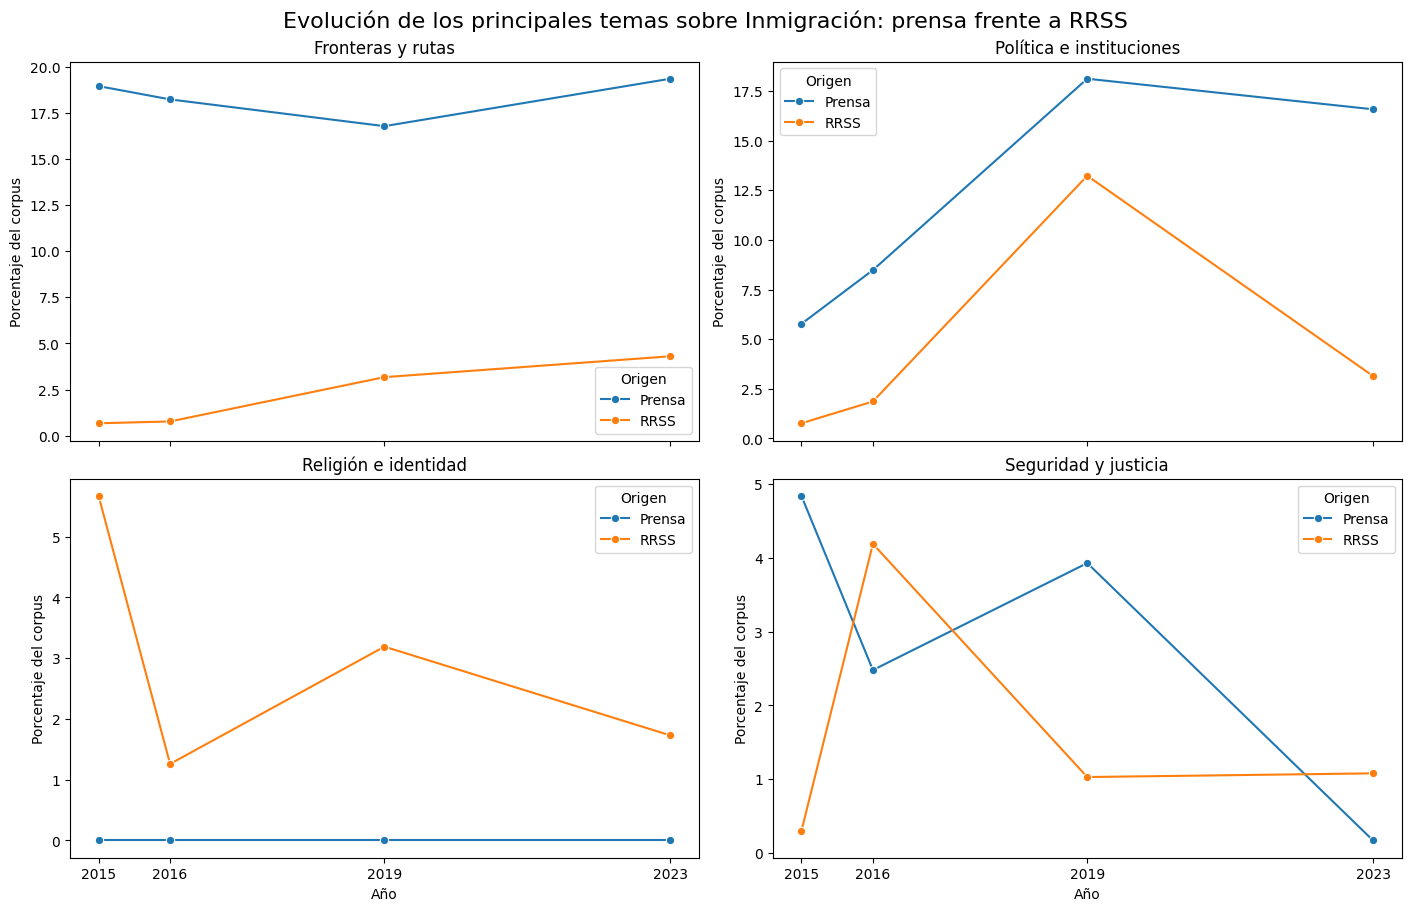

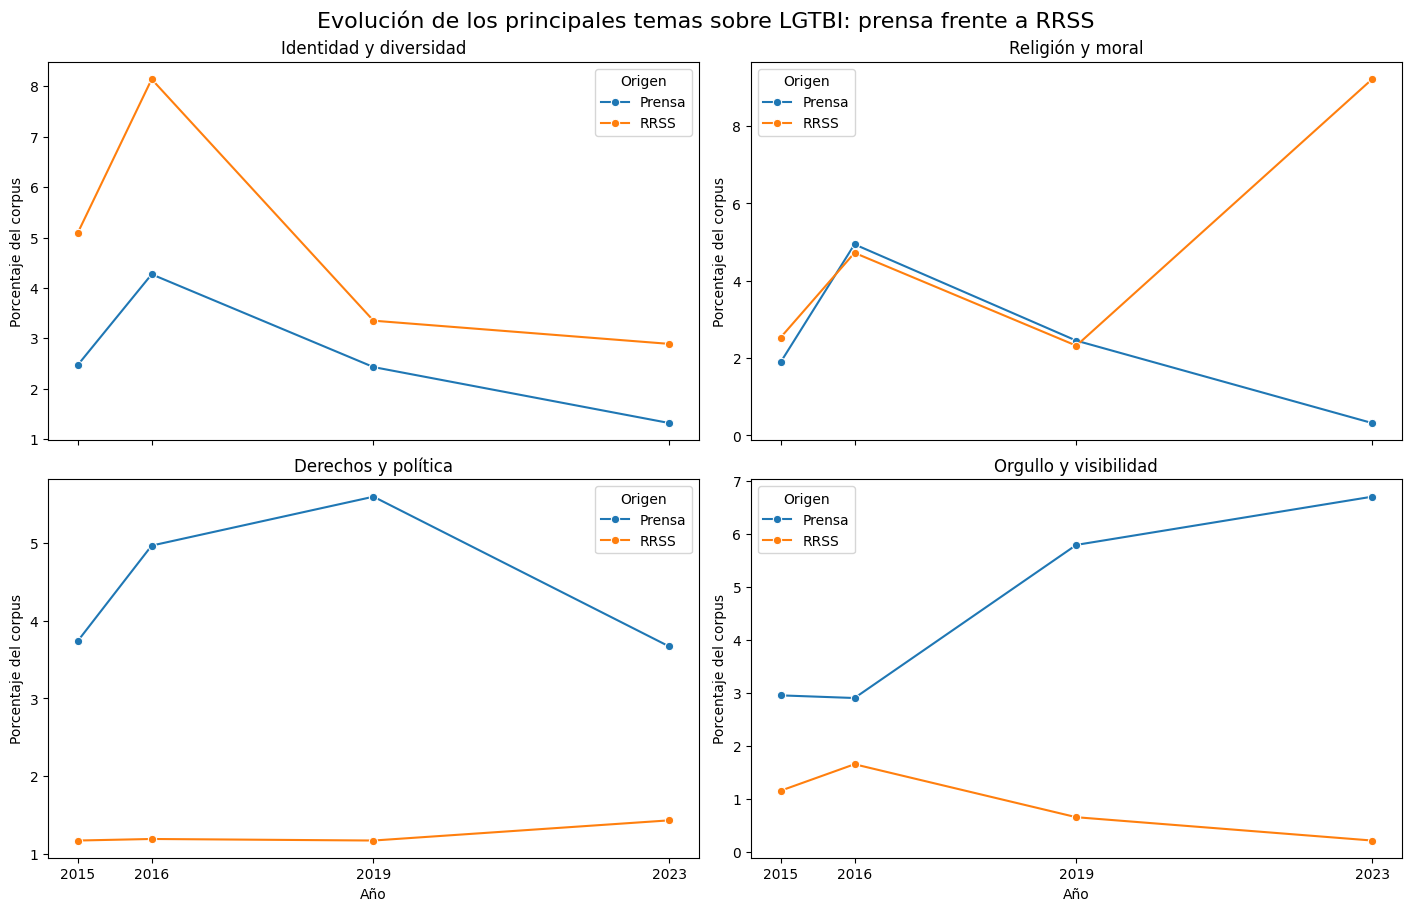

In [ ]:
graficar_evolucion_macros(
    distribucion_macro,
    "Inmigración"
)

graficar_evolucion_macros(
    distribucion_macro,
    "LGTBI"
)